# Utilities

## Librairies

In [72]:
import kagglehub
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

## Data loading

In [ ]:
# path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database", output_dir="../data/raw")
# print("Path to dataset files:", path)

Path to dataset files: ../data/raw


In [ ]:
# !ls "..//kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/images"

'ls' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [ ]:
normal_path = os.path.join(DATA_PATH, "Normal", "images")
covid_path = os.path.join(DATA_PATH, "COVID", "images")
lung_opacity_path = os.path.join(DATA_PATH, "Lung_Opacity", "images")
viral_pneumonia_path = os.path.join(DATA_PATH, "Viral Pneumonia", "images")

paths = {
    'Normal': normal_path,
    'COVID': covid_path,
    'Lung Opacity': lung_opacity_path,
    'Viral Pneumonia': viral_pneumonia_path
}

In [61]:
try:
    df_stats = pd.read_csv("../data/dataset_pixel_statistics.csv")
except Exception as e:
    print(f"df_stats non chargé: {e}")
    df_stats = None

if isinstance(df_stats, pd.DataFrame):
    display(df_stats.head())


,class,image_name,height,width,min_pixel,max_pixel,mean_pixel,std_pixel
0,COVID,COVID-1.png,299,299,0,255,145.896847,51.816632
1,COVID,COVID-10.png,299,299,0,227,141.355466,40.623291
2,COVID,COVID-100.png,299,299,0,255,152.878570,73.778044
3,COVID,COVID-1000.png,299,299,0,252,162.771054,76.249129
4,COVID,COVID-1001.png,299,299,0,242,129.890784,66.179559


# Data exploration

In [2]:
# DATA_PATH = "../data/raw/Covid-19_Radiography_Dataset"
DATA_PATH = "../data/raw"
os.listdir(DATA_PATH)

['COVID',
 'COVID.metadata.xlsx',
 'Lung_Opacity',
 'Lung_Opacity.metadata.xlsx',
 'Normal',
 'Normal.metadata.xlsx',
 'README.md.txt',
 'Viral Pneumonia',
 'Viral Pneumonia.metadata.xlsx']

In [3]:
normal_metadata = pd.read_excel(os.path.join(DATA_PATH, "Normal.metadata.xlsx"))
covid_metadata = pd.read_excel(os.path.join(DATA_PATH, "COVID.metadata.xlsx"))
lung_opacity_metadata = pd.read_excel(os.path.join(DATA_PATH, "Lung_Opacity.metadata.xlsx"))
viral_pneumonia_metadata = pd.read_excel(os.path.join(DATA_PATH, "Viral Pneumonia.metadata.xlsx"))

In [57]:
metadata_full = [
    (normal_metadata, "normal"),
    (covid_metadata, "covid"),
    (lung_opacity_metadata, "lung_opacity"),
    (viral_pneumonia_metadata, "viral_pneumonia"),
]

for metadata in metadata_full:
    print(f"{metadata[1]} data size: {metadata[0].shape}:")
    display(metadata[0].head())
    print()


normal data size: (10192, 4):


,FILE NAME,FORMAT,SIZE,URL
0,NORMAL-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,NORMAL-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
2,NORMAL-3,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
3,NORMAL-4,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
4,NORMAL-5,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...



covid data size: (3616, 4):


,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
2,COVID-3,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
3,COVID-4,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
4,COVID-5,PNG,256*256,https://sirm.org/category/senza-categoria/covi...



lung_opacity data size: (6012, 4):


,FILE NAME,FORMAT,SIZE,URL
0,Lung_Opacity-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,Lung_Opacity-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
2,Lung_Opacity-3,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
3,Lung_Opacity-4,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
4,Lung_Opacity-5,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...



viral_pneumonia data size: (1345, 4):


,FILE NAME,FORMAT,SIZE,URL
0,Viral Pneumonia-1,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
1,Viral Pneumonia-2,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
2,Viral Pneumonia-3,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
3,Viral Pneumonia-4,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
4,Viral Pneumonia-5,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...


# Data visualisation

## Functions

In [ ]:
# Une fonction pour afficher aléatoirement des echantillons de données
def show_examples(class_name, masked=False):
  path = paths[class_name]
  images = os.listdir(path)
  np.random.seed(42)
  
  if not masked:
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))

    for i in range(5):
      selected = images[np.random.randint(0, len(images))]
      selected_path = os.path.join(path, selected)
      image = plt.imread(selected_path)
      axs[0, 0].set_ylabel("IMAGES", fontsize=12)
      axs[i].imshow(image, cmap="gray")
      axs[i].set_title(selected)
      
  else:
    fig, axs = plt.subplots(3, 5, figsize=(15, 9))

    for i in range(5):
      selected = images[np.random.randint(0, len(images), )]
      selected_path = os.path.join(path, selected)
      image = plt.imread(selected_path)
      image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if len(image.shape) == 3 else image
      mask = plt.imread(selected_path.replace("images", "masks"))
      mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
      mask_resized = cv2.resize(mask_gray, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
      mask_bin = (mask_resized > 0).astype(image.dtype)
      image_masked = image * mask_bin
      axs[0, 0].set_ylabel("IMAGES", fontsize=12)
      axs[0, i].imshow(image, cmap="gray")
      axs[0, i].set_title(selected)
      axs[1, 0].set_ylabel("MASKS", fontsize=12)
      axs[1, i].imshow(mask_gray, cmap="gray")
      axs[2, 0].set_ylabel("MASKED IMAGES", fontsize=12)
      axs[2, i].imshow(image_masked, cmap="gray")

In [ ]:
# Une fonctions qui compte le nombre d'occurences par shape et retourne le dictionnaires des shapes et de leur fréquence
def check_shapes(class_name, data="images"):
  path = paths[class_name].replace("images", data)
  images = os.listdir(path)
  shapes = {}
  for image in images:
    img = plt.imread(os.path.join(path, image))
    shape = img.shape
    if shape in shapes:
      shapes[shape] += 1
    else:
      shapes[shape] = 1
  return shapes

In [ ]:
# Retourne un array applati de toutes les intensités de pixels
def analyze_pixels(class_name):
    path = paths[class_name]
    all_pixels = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        all_pixels.append(img.flatten())
    return np.concatenate(all_pixels)

# Retourne les moyennes d'intensité de pixels des images
def analyze_pixels_means(class_name):
    path = paths[class_name]
    pixels_means = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        pixels_means.append(img.mean())
    return pixels_means

# Retourne les moyennes d'intensité de pixels des images masquées en zones segmentées
def analyze_masked_pixels_means(class_name):
    path = paths[class_name]
    pixels_masked_means = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        mask = plt.imread(os.path.join(path.replace("images", "masks"), fname))
        mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
        mask_resized = cv2.resize(mask_gray, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = mask_resized > 0
        lung_pixels  = img[mask_bin]
        pixels_masked_means.append(lung_pixels.mean())
    return pixels_masked_means

# Retourne les écarts-types d'intensité de pixels des images
def analyze_pixels_std(class_name):
    path = paths[class_name]
    pixels_std = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        pixels_std.append(img.std())
    return pixels_std

# Retourne les écarts-types d'intensité de pixels des images masquées en zones segmentées
def analyze_masked_pixels_std(class_name):
    path = paths[class_name]
    pixels_masked_std = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        mask = plt.imread(os.path.join(path.replace("images", "masks"), fname))
        mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
        mask_resized = cv2.resize(mask_gray, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = mask_resized > 0
        lung_pixels  = img[mask_bin]
        pixels_masked_std.append(lung_pixels.std())
    return pixels_masked_std

# Retourne les quantités de pixels des images masquées en zones segmentées
def analyze_masked_images_size(class_name):
    path = paths[class_name]
    masked_len = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        mask = plt.imread(os.path.join(path.replace("images", "masks"), fname))
        mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
        mask_resized = cv2.resize(mask_gray, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = mask_resized > 0
        lung_pixels  = img[mask_bin]
        masked_len.append(len(lung_pixels))
    return masked_len

# Retourne les ratios de pixels noirs des images masquées recadrées
def analyze_masked_images_zeros(class_name):
    path = paths[class_name]
    masked_zeros = []
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = plt.imread(os.path.join(path.replace("images", "masks"), fname))
        mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
        mask_resized = cv2.resize(mask_gray, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = mask_resized > 0
        masked_img = img*mask_bin
        coords = np.argwhere(mask_resized > 0)
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        cropped_img = masked_img[y_min:y_max+1, x_min:x_max+1]
        height_masked, width_masked = cropped_img.shape
        masked_zeros.append((cropped_img == 0).sum() / (height_masked * width_masked))
    return masked_zeros

In [149]:
def crop_black_borders(image):
    """
    image : image grayscale (H, W)

    retourne :
        cropped_image
    """

    # coordonnées des pixels non noirs
    coords = np.argwhere(image > 0)

    # sécurité si image entièrement noire
    if len(coords) == 0:
        return image

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped_image = image[
        y_min:y_max+1,
        x_min:x_max+1
    ]

    return cropped_image


## Some samples

#### Healthy Lungs

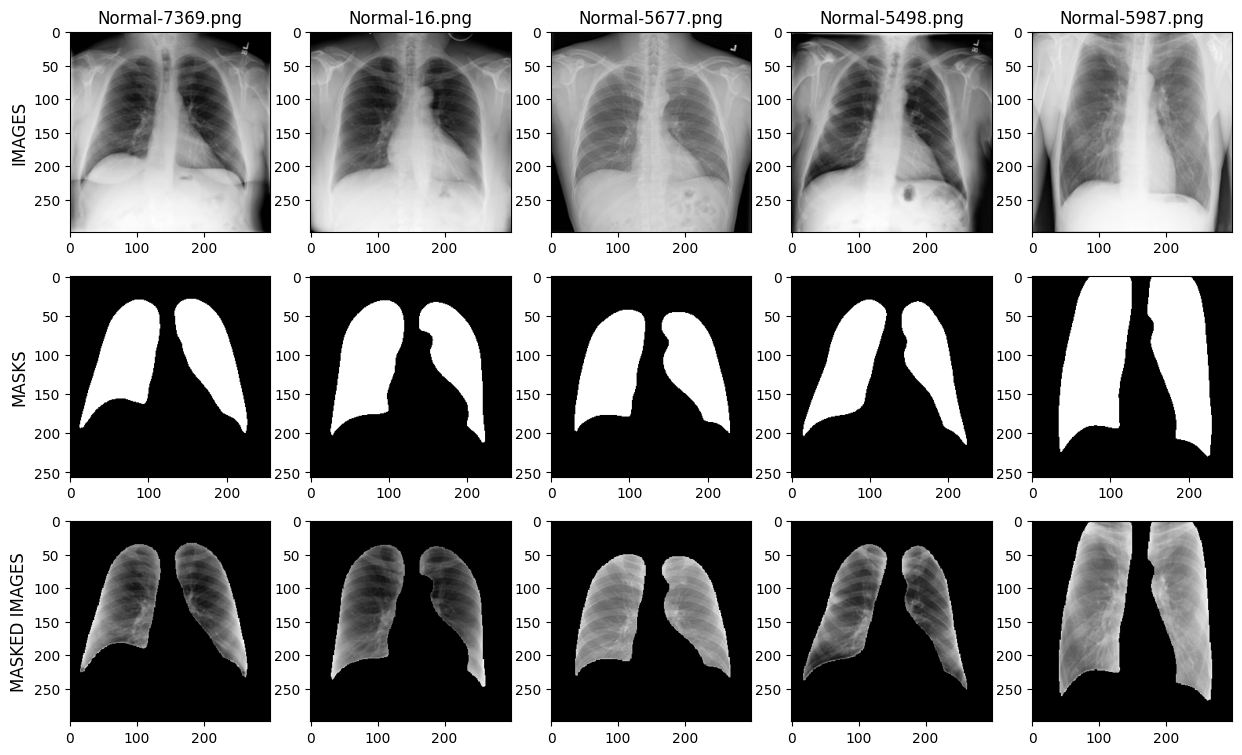

In [ ]:
show_examples("Normal", masked=True)

#### Affected lungs (COVID 19)

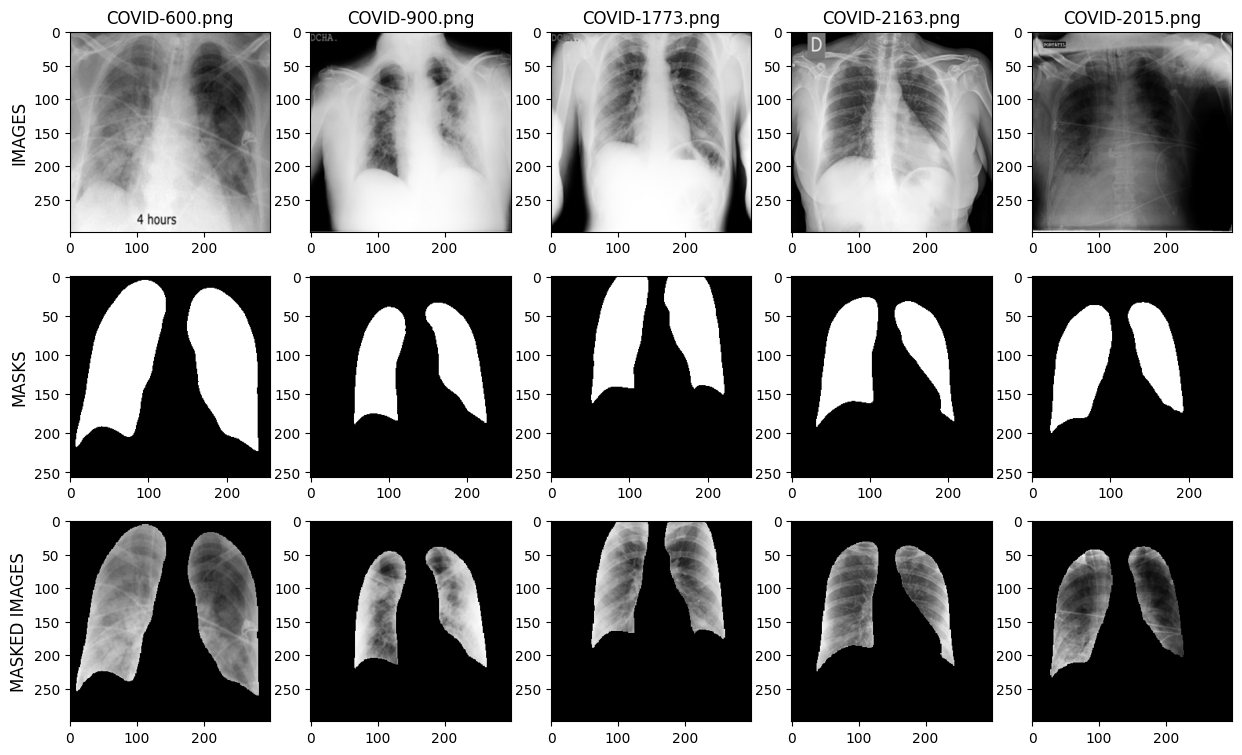

In [ ]:
show_examples("COVID", masked=True)

#### Affected lungs (Lung Opacity)

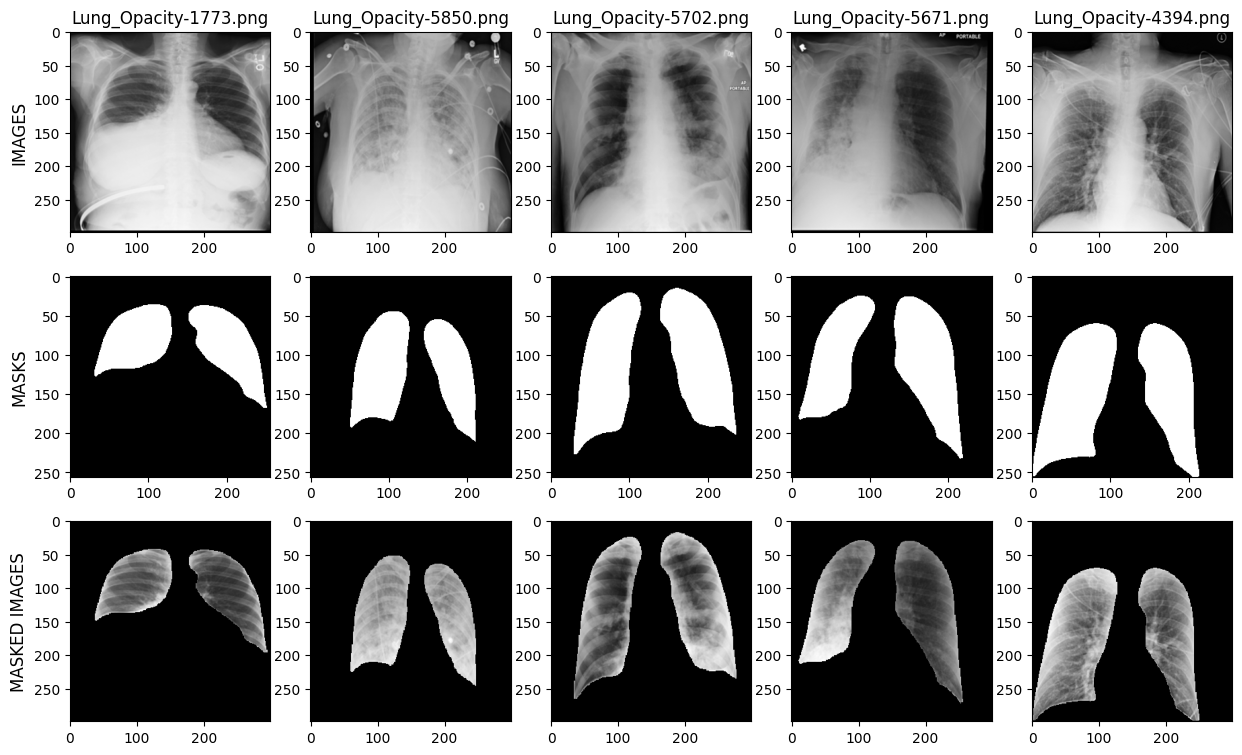

In [ ]:
show_examples("Lung Opacity", masked=True)

#### Affected Lungs (Viral Pneumonia)

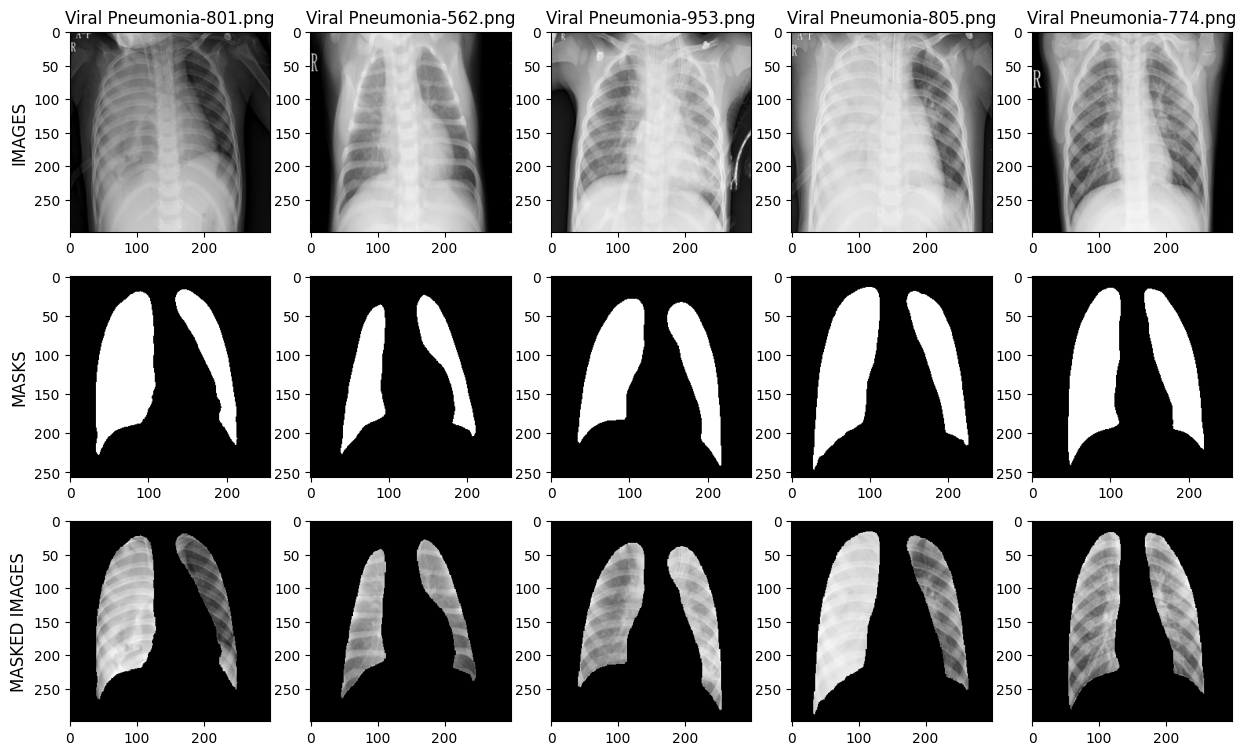

In [ ]:
show_examples("Viral Pneumonia", masked=True)

## Some stats

### <font color="red">**Classes**</font> distribution

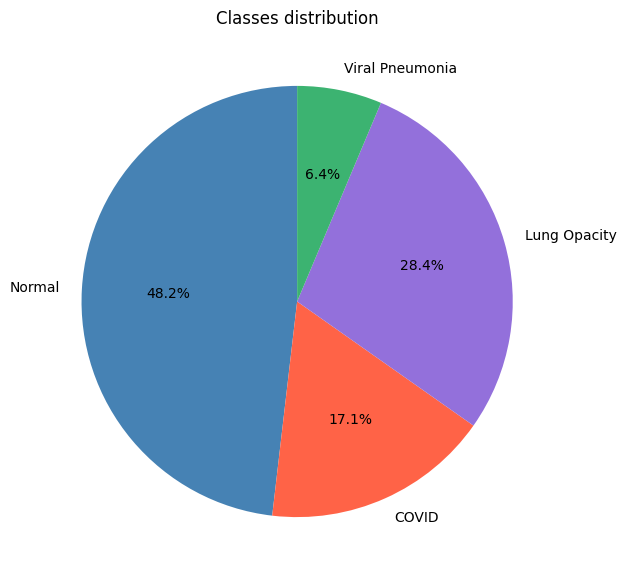

In [62]:
normal_count = normal_metadata.shape[0]
covid_count = covid_metadata.shape[0]
lung_opacity_count = lung_opacity_metadata.shape[0]
viral_pneumonia_count = viral_pneumonia_metadata.shape[0]

labels = ['Normal', 'COVID', 'Lung Opacity', 'Viral Pneumonia', 'Total Affected']
counts = [normal_count, covid_count, lung_opacity_count, viral_pneumonia_count, covid_count + lung_opacity_count + viral_pneumonia_count]

plt.figure(figsize=(7, 7))
plt.pie(counts[:-1], labels=labels[:-1], colors=['steelblue', 'tomato', 'mediumpurple', 'mediumseagreen', 'salmon'],
        autopct='%1.1f%%', startangle=90)
plt.title('Classes distribution')
plt.show()

We have imbalanced classes.

### <font color="red">**Image and mask dimensions**</font> distribution per class

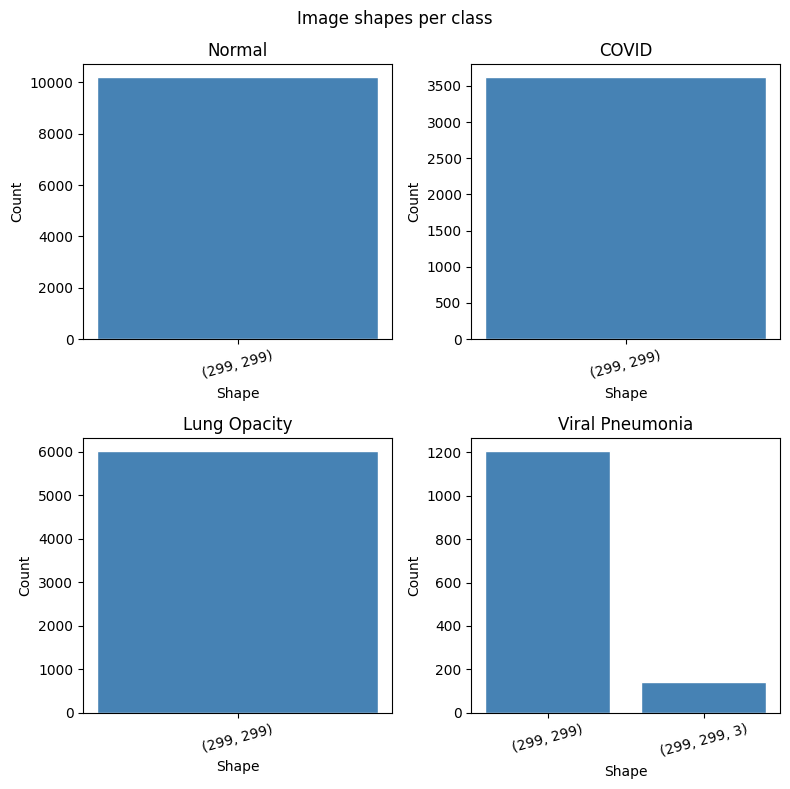

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, (class_name, path) in zip(axes.flatten(), paths.items()):
    shapes = check_shapes(class_name, "images")
    labels = [str(k) for k in shapes.keys()]
    counts = list(shapes.values())
    ax.bar(labels, counts, color='steelblue', edgecolor='white')
    ax.set_title(class_name)
    ax.set_xlabel('Shape')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Image shapes per class')
plt.tight_layout()
plt.show()

A few "viral pneumonia" samples are RGB images with 3 color channels. We need to convert them to Greyscale images so that our futur model always sees the same data type

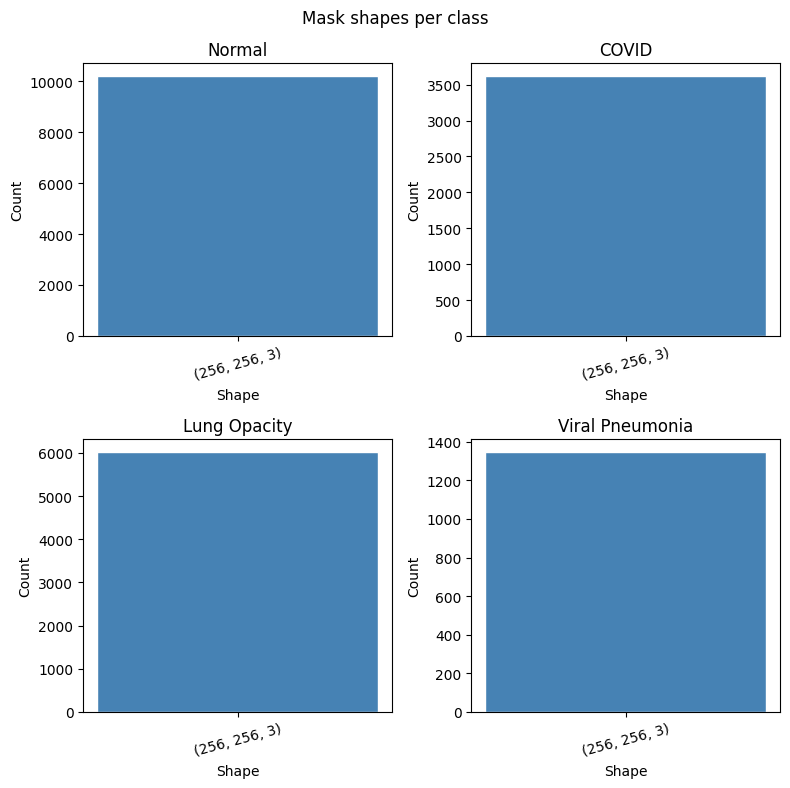

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, (class_name, path) in zip(axes.flatten(), paths.items()):
    shapes = check_shapes(class_name, "masks")
    labels = [str(k) for k in shapes.keys()]
    counts = list(shapes.values())
    ax.bar(labels, counts, color='steelblue', edgecolor='white')
    ax.set_title(class_name)
    ax.set_xlabel('Shape')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Mask shapes per class')
plt.tight_layout()
plt.show()

In [14]:
from PIL import Image

def preprocess_dataset():
    images = os.listdir(viral_pneumonia_path)
    for fname in images:
        img = plt.imread(os.path.join(viral_pneumonia_path, fname))
        if img.shape == (299, 299, 3):
            img_gray = img.mean(axis=2).astype(np.uint8)
            Image.fromarray(img_gray).save(os.path.join(viral_pneumonia_path, fname))

In [16]:
# paths variables
# 'Normal', 'COVID', 'Lung Opacity', 'Viral Pneumonia'

cls_name = "Normal"
path = paths[cls_name]
images = os.listdir(path)
selected = images[np.random.randint(0, len(images))]
selected_path = os.path.join(path, selected)
print(plt.imread(selected_path))
print()
print((plt.imread(selected_path)*255).astype(np.uint8))

[[0.5921569  0.8        0.8392157  ... 0.7921569  0.78431374 0.7058824 ]
 [0.81960785 0.93333334 0.9529412  ... 0.92156863 0.9137255  0.81960785]
 [0.8666667  0.95686275 0.9647059  ... 0.94509804 0.9372549  0.8392157 ]
 ...
 [0.34117648 0.3882353  0.4        ... 0.8235294  0.8039216  0.73333335]
 [0.31764707 0.3647059  0.3764706  ... 0.7176471  0.69803923 0.6431373 ]
 [0.23137255 0.25882354 0.26666668 ... 0.47058824 0.45882353 0.41960785]]

[[151 204 214 ... 202 200 180]
 [209 238 243 ... 235 233 209]
 [221 244 246 ... 241 239 214]
 ...
 [ 87  99 102 ... 210 205 187]
 [ 81  93  96 ... 183 178 164]
 [ 59  66  68 ... 120 117 107]]


Images are normalized in range [0, 1]

Let's expand the pixel values to the range [0, 255]

### <font color="red">**Pixel intensities**</font> distribution per class

In [139]:
pixel_data = {class_name: analyze_pixels(class_name) for class_name in paths}

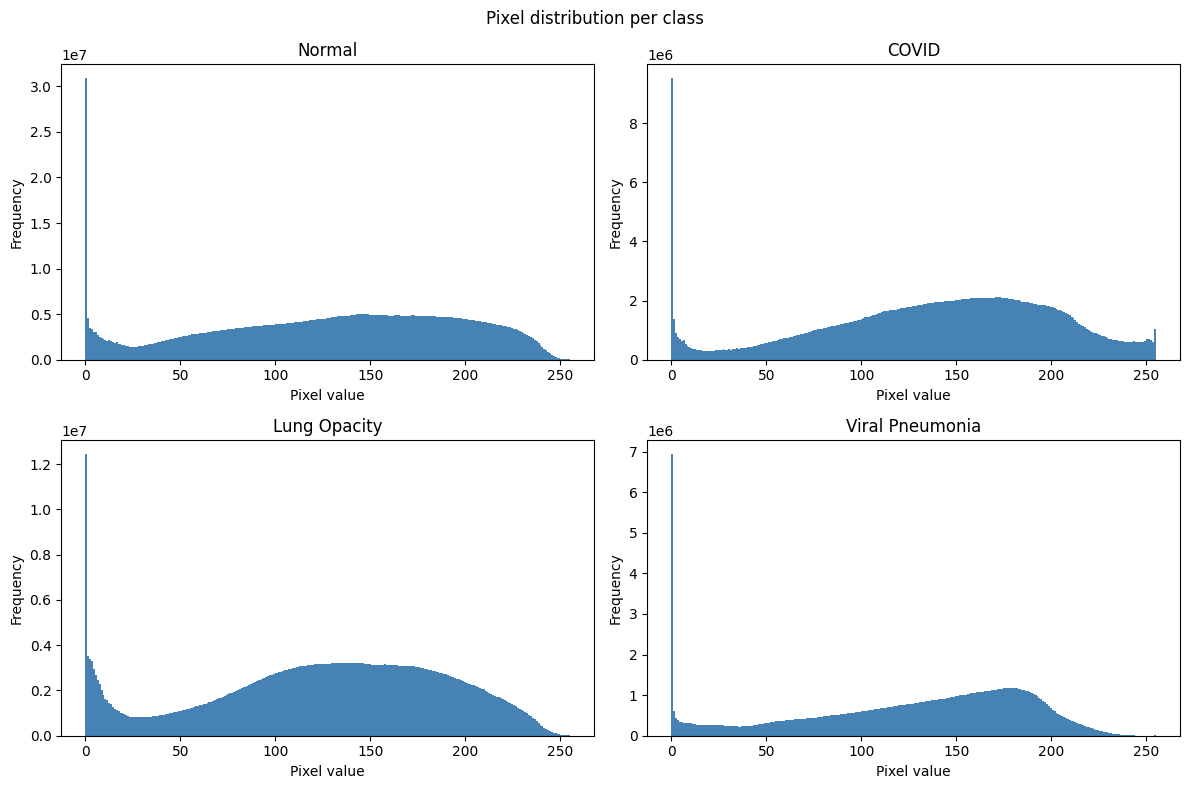

Normal: 0 outlier pixels (0.00%) | range: <-72.0 or >336.0
COVID: 0 outlier pixels (0.00%) | range: <-29.0 or >315.0
Lung Opacity: 0 outlier pixels (0.00%) | range: <-47.5 or >308.5
Viral Pneumonia: 0 outlier pixels (0.00%) | range: <-45.0 or >307.0


In [140]:
# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), pixel_data.items()):
    ax.hist(pixels, bins=256, range=(0, 255), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixel value')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixel distribution per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in pixel_data.items():
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier pixels ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

### <font color="red">**Images pixel intensity means**</font> distribution per class

In [143]:
pixel_mean_data = {class_name: analyze_pixels_means(class_name) for class_name in paths}

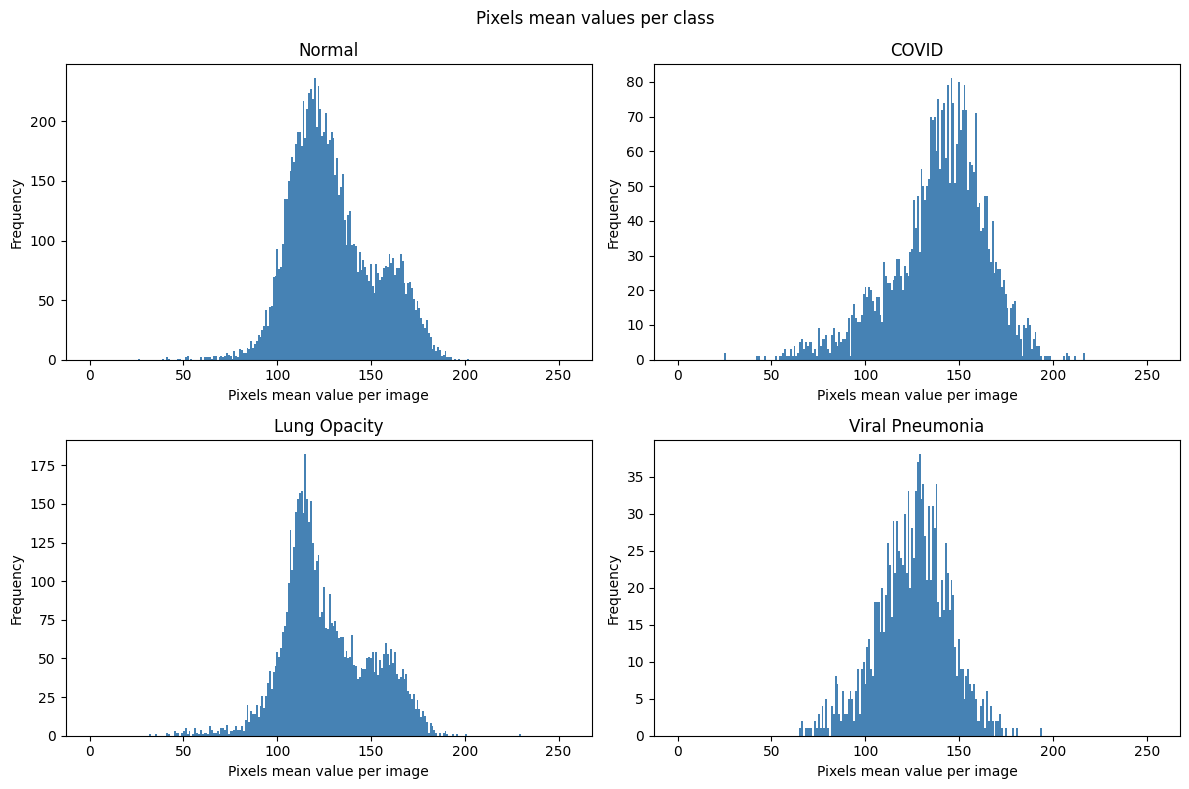

Normal: 0 outlier images (0.00%) | range: <-72.0 or >336.0
COVID: 0 outlier images (0.00%) | range: <-29.0 or >315.0
Lung Opacity: 0 outlier images (0.00%) | range: <-47.5 or >308.5
Viral Pneumonia: 0 outlier images (0.00%) | range: <-45.0 or >307.0


In [144]:
# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), pixel_mean_data.items()):
    ax.hist(pixels, bins=256, range=(0, 255), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixels mean value per image')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixels mean values per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in pixel_data.items():
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier images ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

### <font color="red">**Masked images pixel intensity means**</font> distribution per class

In [ ]:
pixel_masked_mean_data = {class_name: analyze_masked_pixels_means(class_name) for class_name in paths}

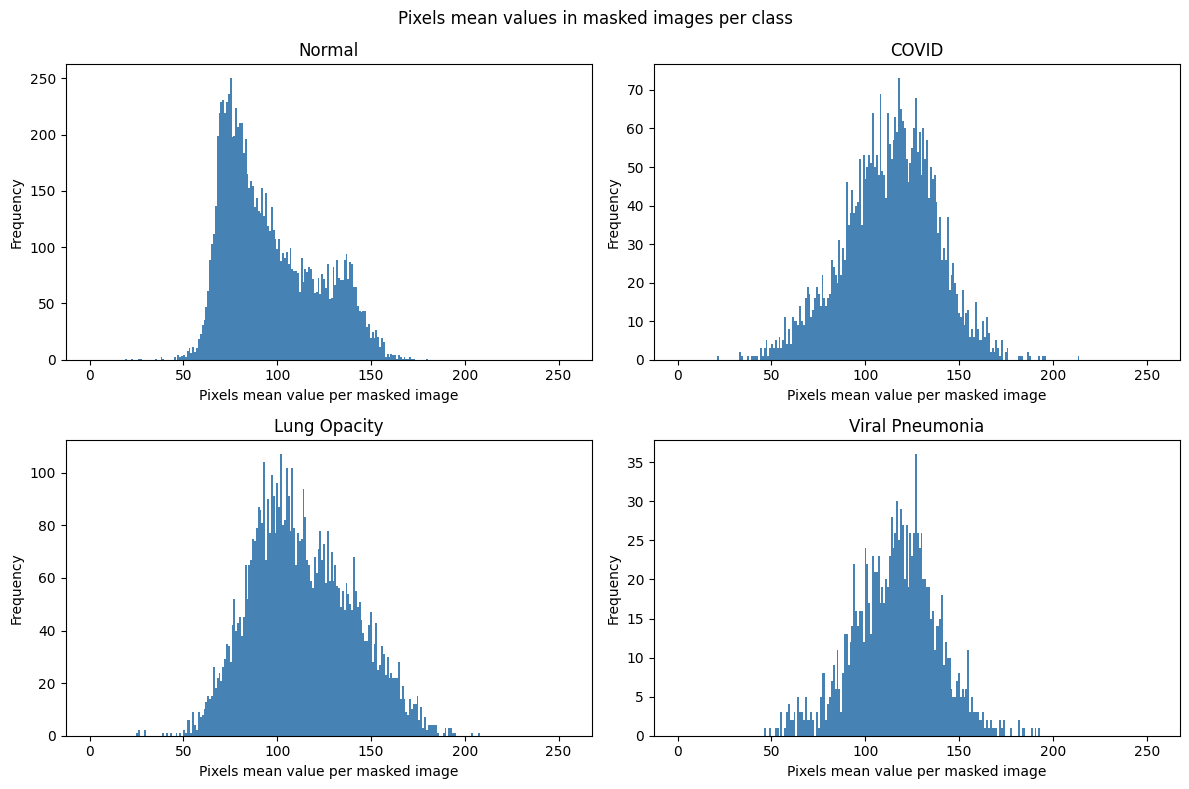

Normal: 2 outlier images (0.02%) | range: <17.8 or >172.3
COVID: 32 outlier images (0.88%) | range: <48.3 or >179.2
Lung Opacity: 15 outlier images (0.25%) | range: <35.0 or >190.6
Viral Pneumonia: 18 outlier images (1.34%) | range: <58.2 or >173.6


In [146]:
# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), pixel_masked_mean_data.items()):
    ax.hist(pixels, bins=256, range=(0, 255), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixels mean value per masked image')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixels mean values in masked images per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in pixel_masked_mean_data.items():
    pixels = np.array(pixels)
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier images ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

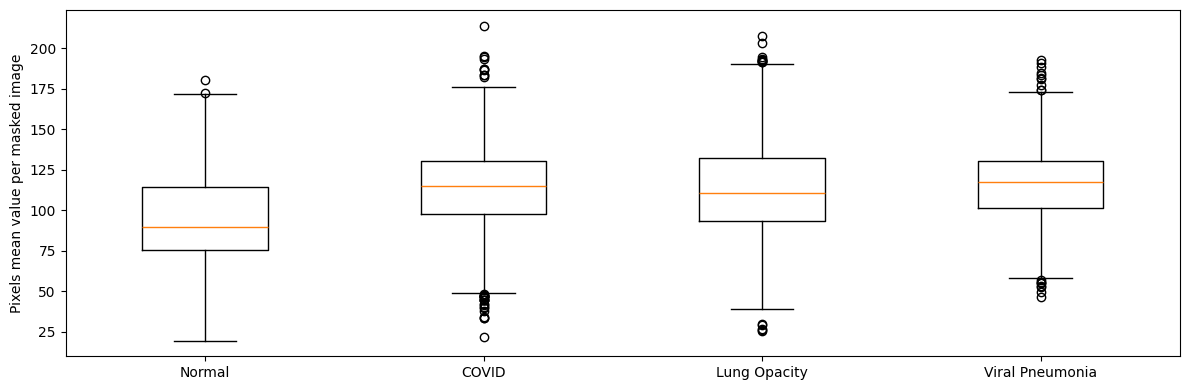

In [98]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.boxplot(
    [pixel_masked_mean_data[cls] for cls in pixel_masked_mean_data],
    tick_labels=list(pixel_masked_mean_data.keys())
)

ax.set_ylabel("Pixels mean value per masked image")

plt.tight_layout()
plt.show()

### <font color="red">**Images pixel intensity standard deviations**</font> distribution per class

In [147]:
pixel_std_data = {class_name: analyze_pixels_std(class_name) for class_name in paths}

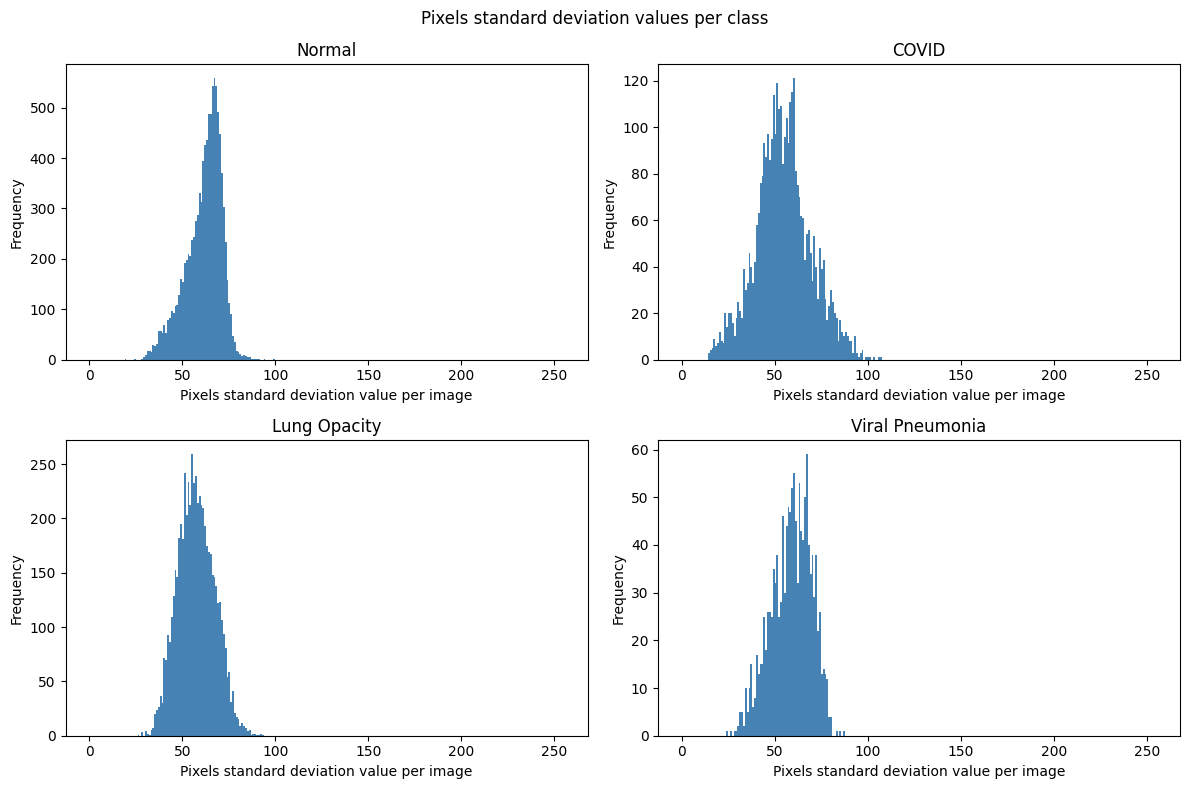

Normal: 0 outlier images (0.00%) | range: <-72.0 or >336.0
COVID: 0 outlier images (0.00%) | range: <-29.0 or >315.0
Lung Opacity: 0 outlier images (0.00%) | range: <-47.5 or >308.5
Viral Pneumonia: 0 outlier images (0.00%) | range: <-45.0 or >307.0


In [148]:
# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), pixel_std_data.items()):
    ax.hist(pixels, bins=256, range=(0, 255), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixels standard deviation value per image')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixels standard deviation values per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in pixel_data.items():
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier images ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

### <font color="red">**Masked images pixel intensity standard deviations**</font> distribution per class

In [ ]:
pixel_masked_std_data = {class_name: analyze_masked_pixels_std(class_name) for class_name in paths}

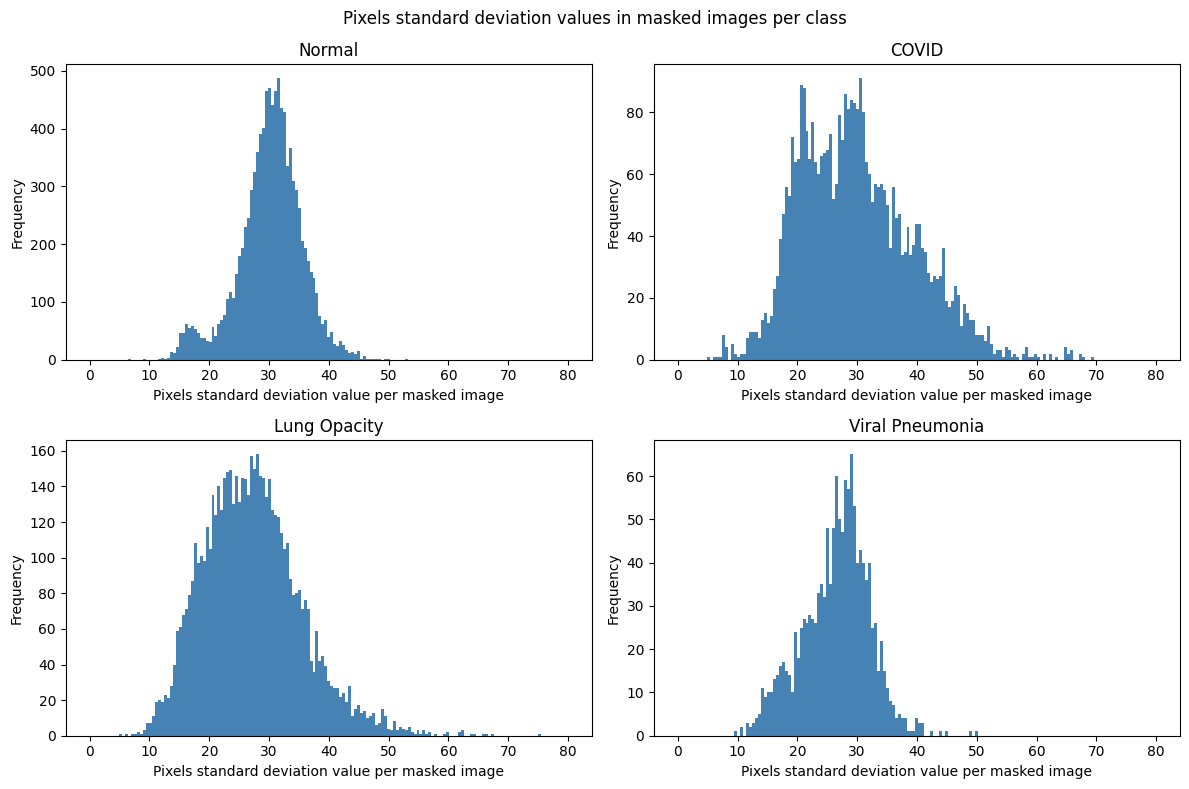

Normal: 506 outlier images (4.96%) | range: <18.3 or >42.6
COVID: 31 outlier images (0.86%) | range: <2.2 or >56.3
Lung Opacity: 99 outlier images (1.65%) | range: <5.4 or >48.0
Viral Pneumonia: 13 outlier images (0.97%) | range: <12.1 or >41.0


In [ ]:
# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), pixel_masked_std_data.items()):
    ax.hist(pixels, bins=161, range=(0, 80), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixels standard deviation value per masked image')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixels standard deviation values in masked images per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in pixel_masked_std_data.items():
    pixels = np.array(pixels)
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier images ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

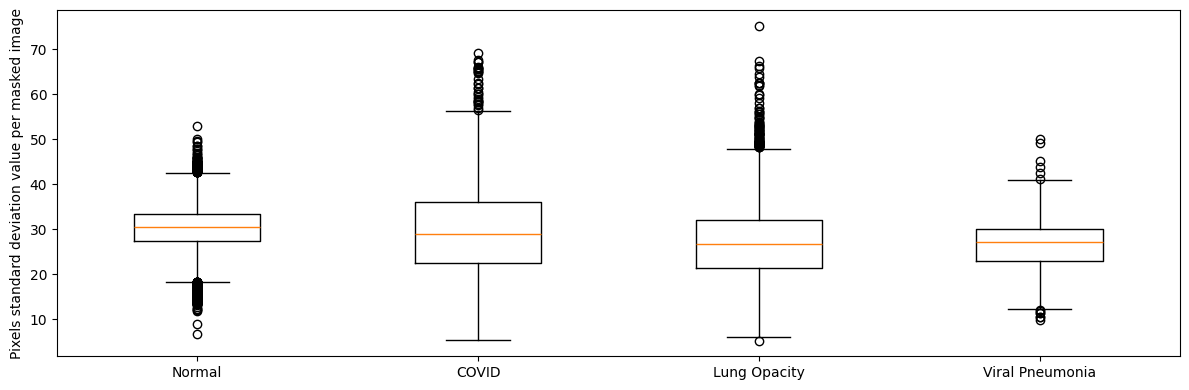

In [99]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.boxplot(
    [pixel_masked_std_data[cls] for cls in pixel_masked_std_data],
    tick_labels=list(pixel_masked_std_data.keys())
)

ax.set_ylabel("Pixels standard deviation value per masked image")

plt.tight_layout()
plt.show()

### <font color="red">**Masked images pixel quantities**</font> distribution per class

In [ ]:
path = DATA_PATH + "/COVID/images/"
fname = "COVID-1.png"
img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
mask = plt.imread(os.path.join(path.replace("images", "masks"), fname))
mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
mask_resized = cv2.resize(mask_gray, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
mask_bin = mask_resized > 0
lung_pixels  = img[mask_bin]
print(len(img.flatten()), len(lung_pixels.flatten()))


89401 20931


In [ ]:
masked_len_data = {class_name: analyze_masked_images_size(class_name) for class_name in paths}

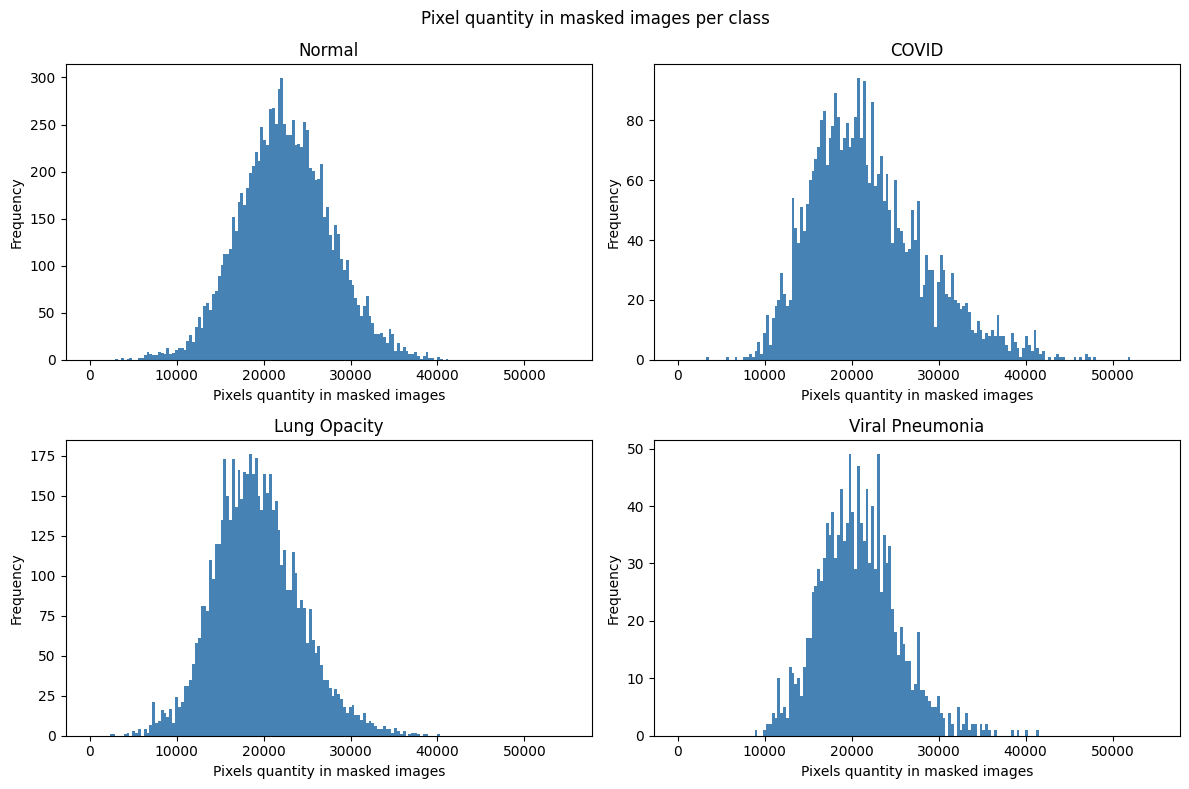

Normal: 113 outlier images (1.11%) | range: <8645.4 or >36260.4
COVID: 68 outlier images (1.88%) | range: <4161.4 or >38540.4
Lung Opacity: 84 outlier images (1.40%) | range: <6131.2 or >31961.2
Viral Pneumonia: 25 outlier images (1.86%) | range: <8847.0 or >32287.0


In [ ]:
# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), masked_len_data.items()):
    ax.hist(pixels, bins=168, range=(0, 55000), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixels quantity in masked images')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixel quantity in masked images per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in masked_len_data.items():
    pixels = np.array(pixels)
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier images ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

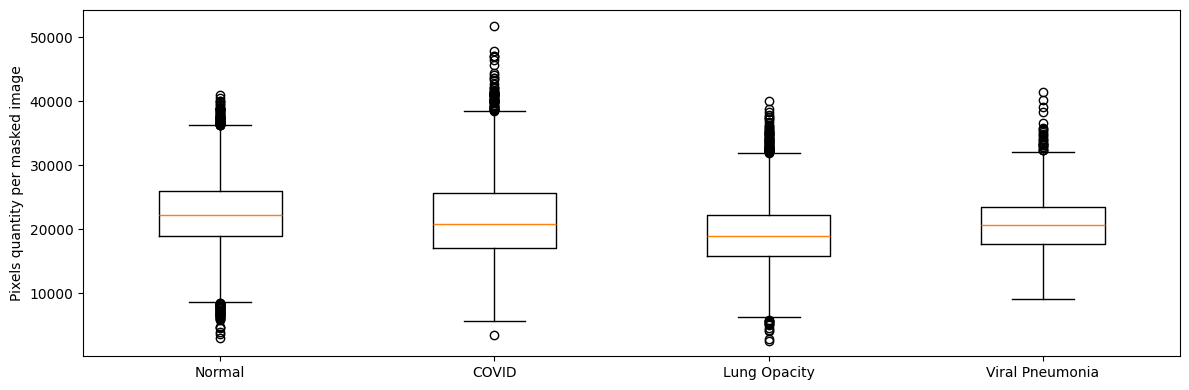

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.boxplot(
    [masked_len_data[cls] for cls in masked_len_data],
    tick_labels=list(masked_len_data.keys())
)

ax.set_ylabel("Pixels quantity per masked image")

plt.tight_layout()
plt.show()

### <font color="red">**Masked images zero-ratios**</font> distribution per class

In [108]:
path = DATA_PATH + "/COVID/images/"
fname = "COVID-1.png"
img = (plt.imread(os.path.join(path, fname))*255).astype(np.uint8)
mask = plt.imread(os.path.join(path.replace("images", "masks"), fname))
mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
mask_resized = cv2.resize(mask_gray, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
mask_bin = mask_resized > 0
lung_pixels  = img[mask_bin]
masked_img = img*mask_bin
coords = np.argwhere(mask_resized > 0)
y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)
cropped_img = masked_img[y_min:y_max+1, x_min:x_max+1]
print(img.shape, cropped_img.shape)


(299, 299) (193, 222)


In [ ]:
masked_zeros_data = {class_name: analyze_masked_images_zeros(class_name) for class_name in paths}

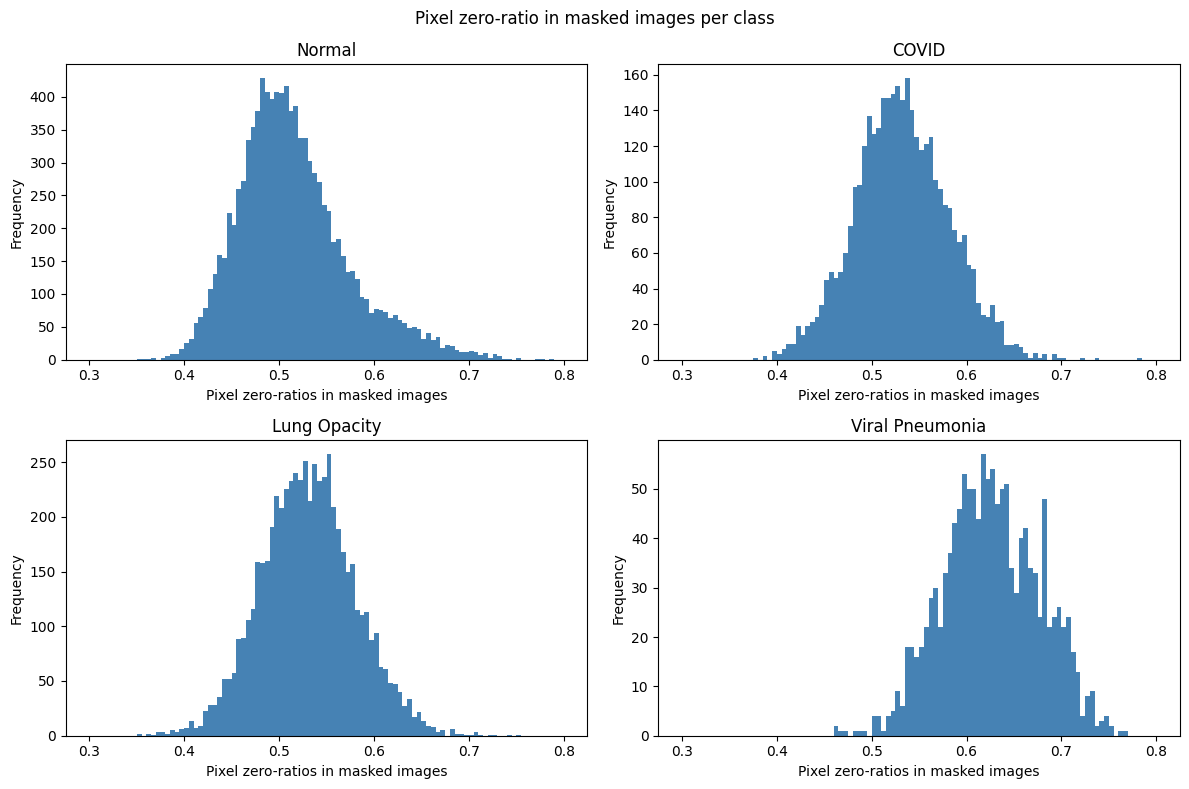

Normal: 308 outlier images (3.02%) | range: <0.4 or >0.6
COVID: 27 outlier images (0.75%) | range: <0.4 or >0.7
Lung Opacity: 61 outlier images (1.01%) | range: <0.4 or >0.7
Viral Pneumonia: 5 outlier images (0.37%) | range: <0.5 or >0.8


In [ ]:
# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (class_name, pixels) in zip(axes.flatten(), masked_zeros_data.items()):
    ax.hist(pixels, bins=100, range=(0.3, 0.8), color='steelblue', edgecolor='none')
    ax.set_title(class_name)
    ax.set_xlabel('Pixel zero-ratios in masked images')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixel zero-ratio in masked images per class')
plt.tight_layout()
plt.show()

# outlier stats
for class_name, pixels in masked_zeros_data.items():
    pixels = np.array(pixels)
    Q1, Q3 = np.percentile(pixels, 25), np.percentile(pixels, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = pixels[(pixels < lower) | (pixels > upper)]
    print(f"{class_name}: {len(outliers):,} outlier images ({100*len(outliers)/len(pixels):.2f}%) | range: <{lower:.1f} or >{upper:.1f}")

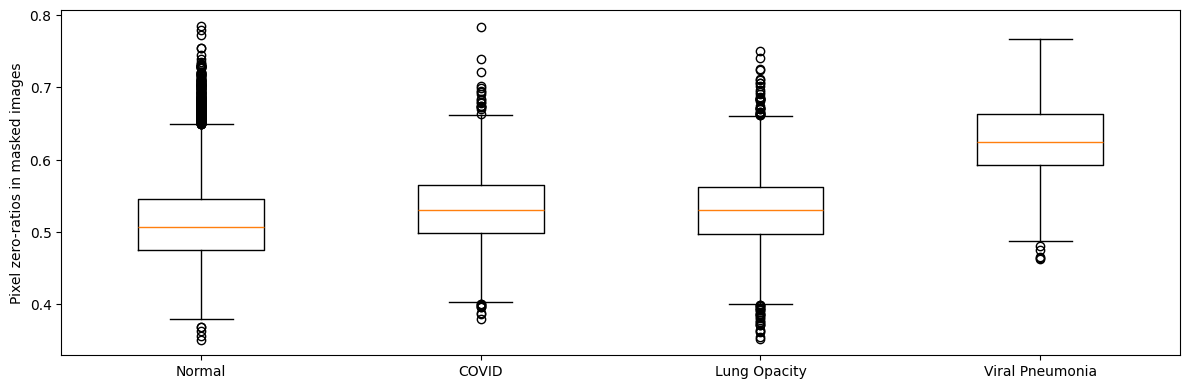

In [114]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.boxplot(
    [masked_zeros_data[cls] for cls in masked_zeros_data],
    tick_labels=list(masked_zeros_data.keys())
)

ax.set_ylabel("Pixel zero-ratios in masked images")

plt.tight_layout()
plt.show()

### Gathering and save stats

In [116]:
classes = ["Normal", "COVID", "Lung Opacity", "Viral Pneumonia"]
data = []
for class_name in classes:
    image_dir = paths[class_name]
    images = os.listdir(image_dir)

    for image_name in tqdm(images, desc=class_name):
        image_path = os.path.join(image_dir, image_name)
        mask_path = image_path.replace("images", "masks")
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = plt.imread(mask_path)
        mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
        mask_resized = cv2.resize(mask_gray, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = mask_resized > 0
        lung_pixels  = image[mask_bin]
        masked_img = img*mask_bin
        coords = np.argwhere(mask_resized > 0)
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        cropped_img = masked_img[y_min:y_max+1, x_min:x_max+1]
        
        min_pixel = np.min(image)
        max_pixel = np.max(image)
        mean_pixel = np.mean(image)
        std_pixel = np.std(image)
        height, width = image.shape
        zero_ratio = (image == 0).sum() / (height * width)
        
        min_pixel_masked = np.min(lung_pixels)
        max_pixel_masked = np.max(lung_pixels)
        mean_pixel_masked = np.mean(lung_pixels)
        std_pixel_masked = np.std(lung_pixels)
        height_masked, width_masked = cropped_img.shape
        pixel_qty_masked = len(lung_pixels)
        zero_ratio_masked = (cropped_img == 0).sum() / (height_masked * width_masked)
        
        # stockage
        data.append({
            "class": class_name,
            "image_name": image_name,
            "height": height,
            "width": width,
            "min_pixel": min_pixel,
            "max_pixel": max_pixel,
            "mean_pixel": mean_pixel,
            "std_pixel": std_pixel,
            "zero_ratio": zero_ratio,
            "height_masked": height_masked,
            "width_masked": width_masked,
            "min_pixel_masked": min_pixel_masked,
            "max_pixel_masked": max_pixel_masked,
            "mean_pixel_masked": mean_pixel_masked,
            "std_pixel_masked": std_pixel_masked,
            "zero_ratio_masked": zero_ratio_masked,
            "pixel_qty_masked": pixel_qty_masked,
        })

df_stats = pd.DataFrame(data)
df_stats.to_csv("../data/dataset_pixel_statistics.csv", index=False)

df_stats.head()


Viral Pneumonia: 100%|██████████| 1345/1345 [00:03<00:00, 361.21it/s]


,class,image_name,height,width,min_pixel,max_pixel,mean_pixel,std_pixel,zero_ratio,height_masked,width_masked,min_pixel_masked,max_pixel_masked,mean_pixel_masked,std_pixel_masked,zero_ratio_masked,pixel_qty_masked
0,Normal,Normal-1.png,299,299,0,255,85.189696,71.270032,0.291563,189,200,39,207,100.221798,29.791657,0.445847,20947
1,Normal,Normal-10.png,299,299,0,250,128.524166,65.305603,0.005615,199,244,5,195,72.543050,30.289674,0.514911,23554
2,Normal,Normal-100.png,299,299,0,248,125.679042,59.727077,0.074652,225,232,24,213,97.554271,28.446685,0.575709,22148
3,Normal,Normal-1000.png,299,299,0,253,113.723739,54.612538,0.084417,180,234,23,190,100.041755,23.653639,0.641216,15112
4,Normal,Normal-10000.png,299,299,0,250,131.353195,65.849642,0.017080,193,247,19,205,83.774596,32.248655,0.616853,18265


### Extreme values

#### Pixel quantity in segmented area

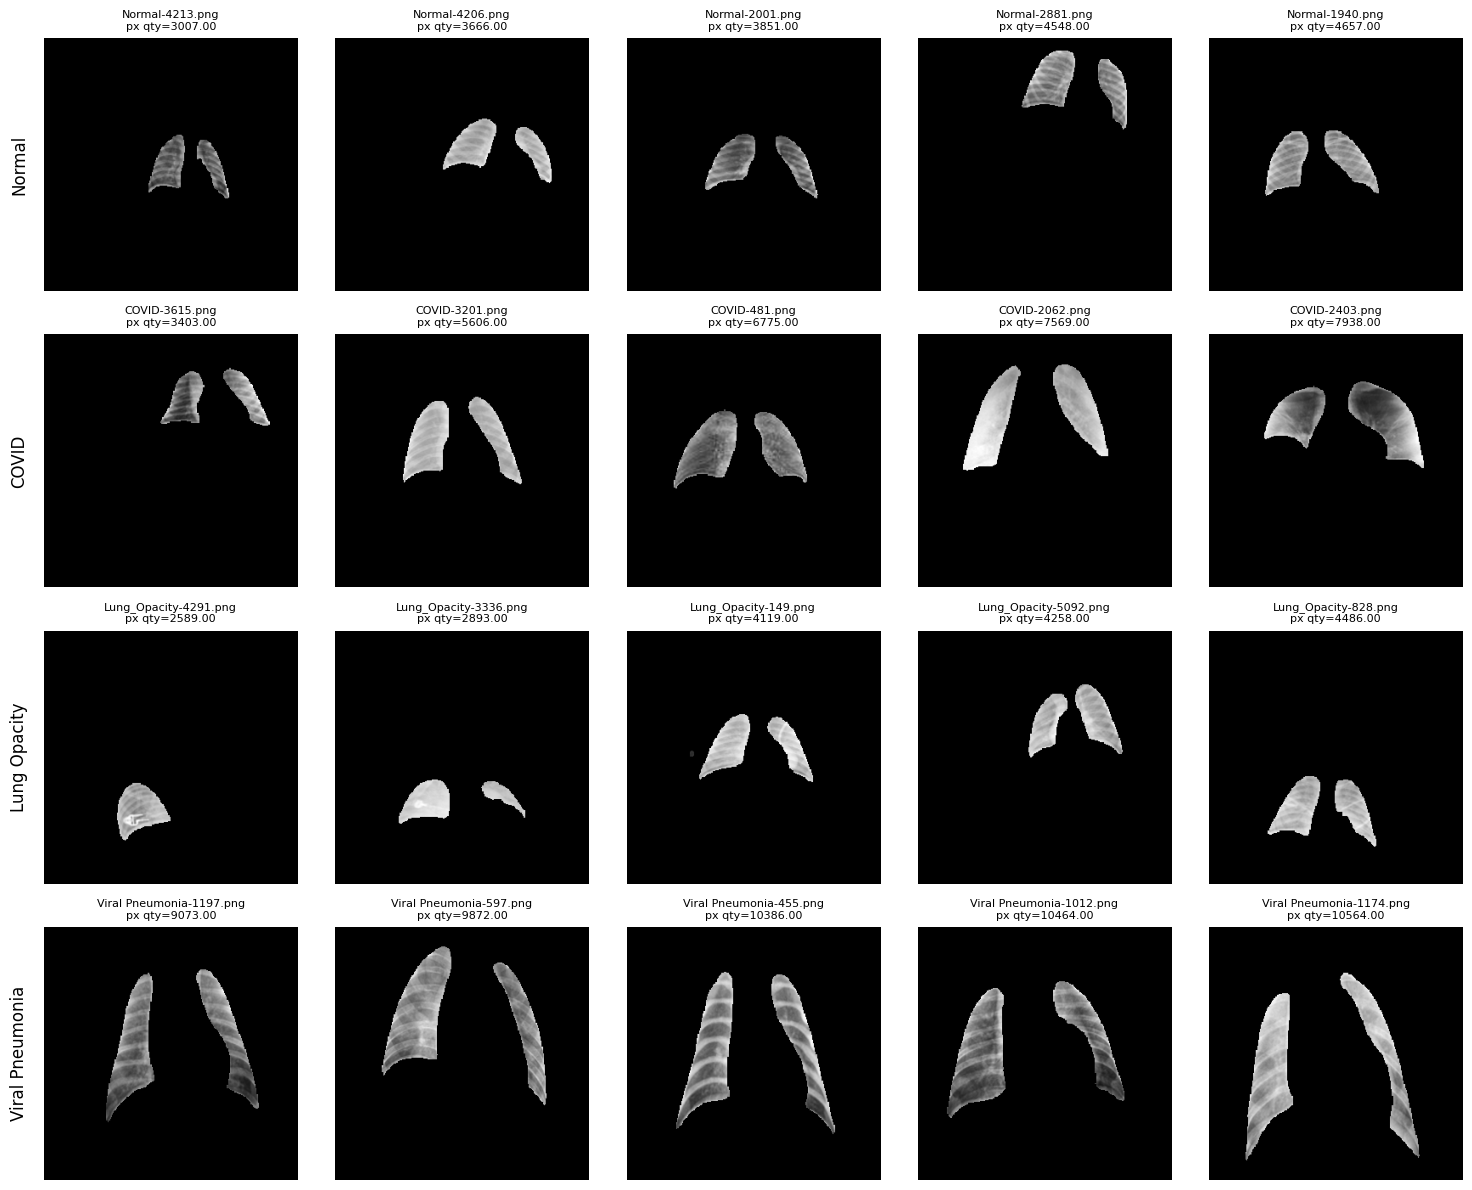

In [ ]:
# 5 images segmentées avec les quantités de pixels les plus faibles par classe

classes = ["Normal", "COVID", "Lung Opacity", "Viral Pneumonia"]

fig, axs = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for row_idx, cls in enumerate(classes):
    
    class_images = (df_stats[df_stats["class"] == cls].nsmallest(5, "pixel_qty_masked"))
    
    for col_idx, (_, row) in enumerate(class_images.iterrows()):
        ax = axs[row_idx, col_idx]
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask_path = image_path.replace("images", "masks")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_resized > 0).astype(image.dtype)
        masked_image = image * mask_bin
        ax.imshow(masked_image, cmap="gray")
        ax.set_title(f"{row['image_name']}\npx qty={row['pixel_qty_masked']:.2f}",fontsize=8)
        ax.axis("off")

    # nom de la classe à gauche de la ligne
    axs[row_idx, 0].text(
        -0.10, 0.5,
        cls,
        transform=axs[row_idx, 0].transAxes,
        fontsize=12,
        rotation=90,
        va="center",
        ha="center"
    )

plt.tight_layout()
plt.show()

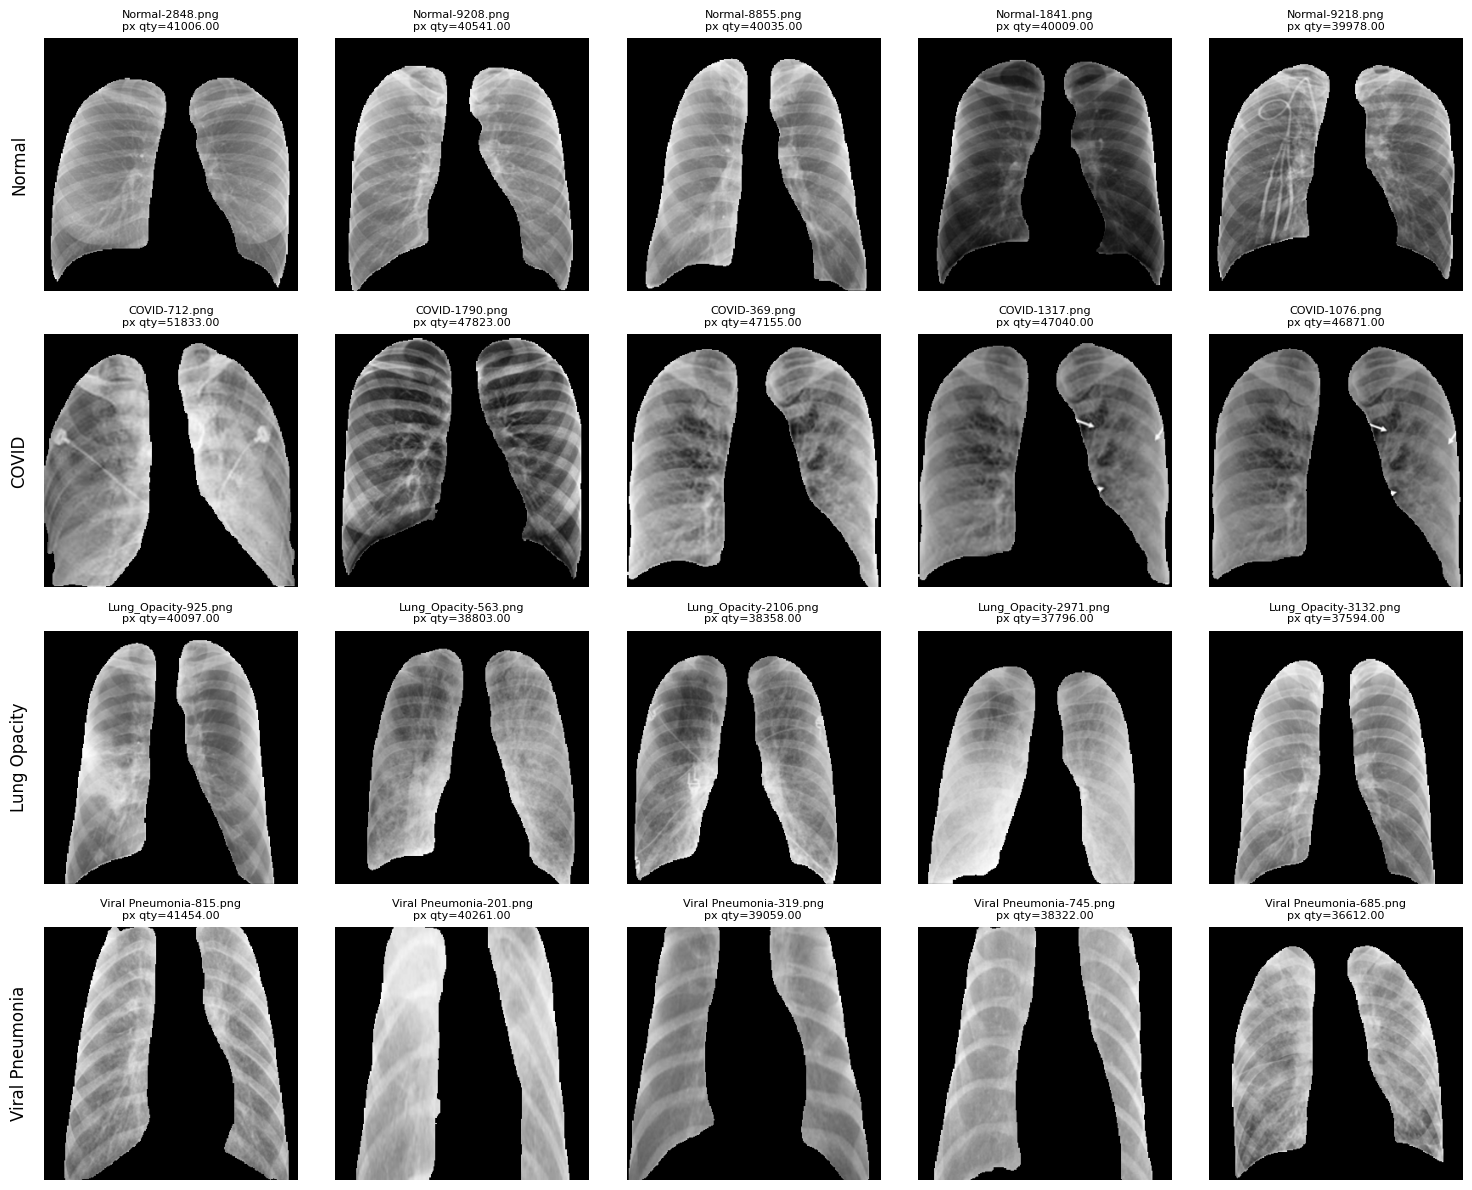

In [ ]:
# 5 images segmentées avec les quantités de pixels les plus élevés par classe

classes = ["Normal", "COVID", "Lung Opacity", "Viral Pneumonia"]

fig, axs = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for row_idx, cls in enumerate(classes):
    
    class_images = (df_stats[df_stats["class"] == cls].nlargest(5, "pixel_qty_masked"))
    
    for col_idx, (_, row) in enumerate(class_images.iterrows()):
        ax = axs[row_idx, col_idx]
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask_path = image_path.replace("images", "masks")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_resized > 0).astype(image.dtype)
        masked_image = image * mask_bin
        ax.imshow(masked_image, cmap="gray")
        ax.set_title(f"{row['image_name']}\npx qty={row['pixel_qty_masked']:.2f}",fontsize=8)
        ax.axis("off")

    # nom de la classe à gauche de la ligne
    axs[row_idx, 0].text(
        -0.10, 0.5,
        cls,
        transform=axs[row_idx, 0].transAxes,
        fontsize=12,
        rotation=90,
        va="center",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Mean in segmented area

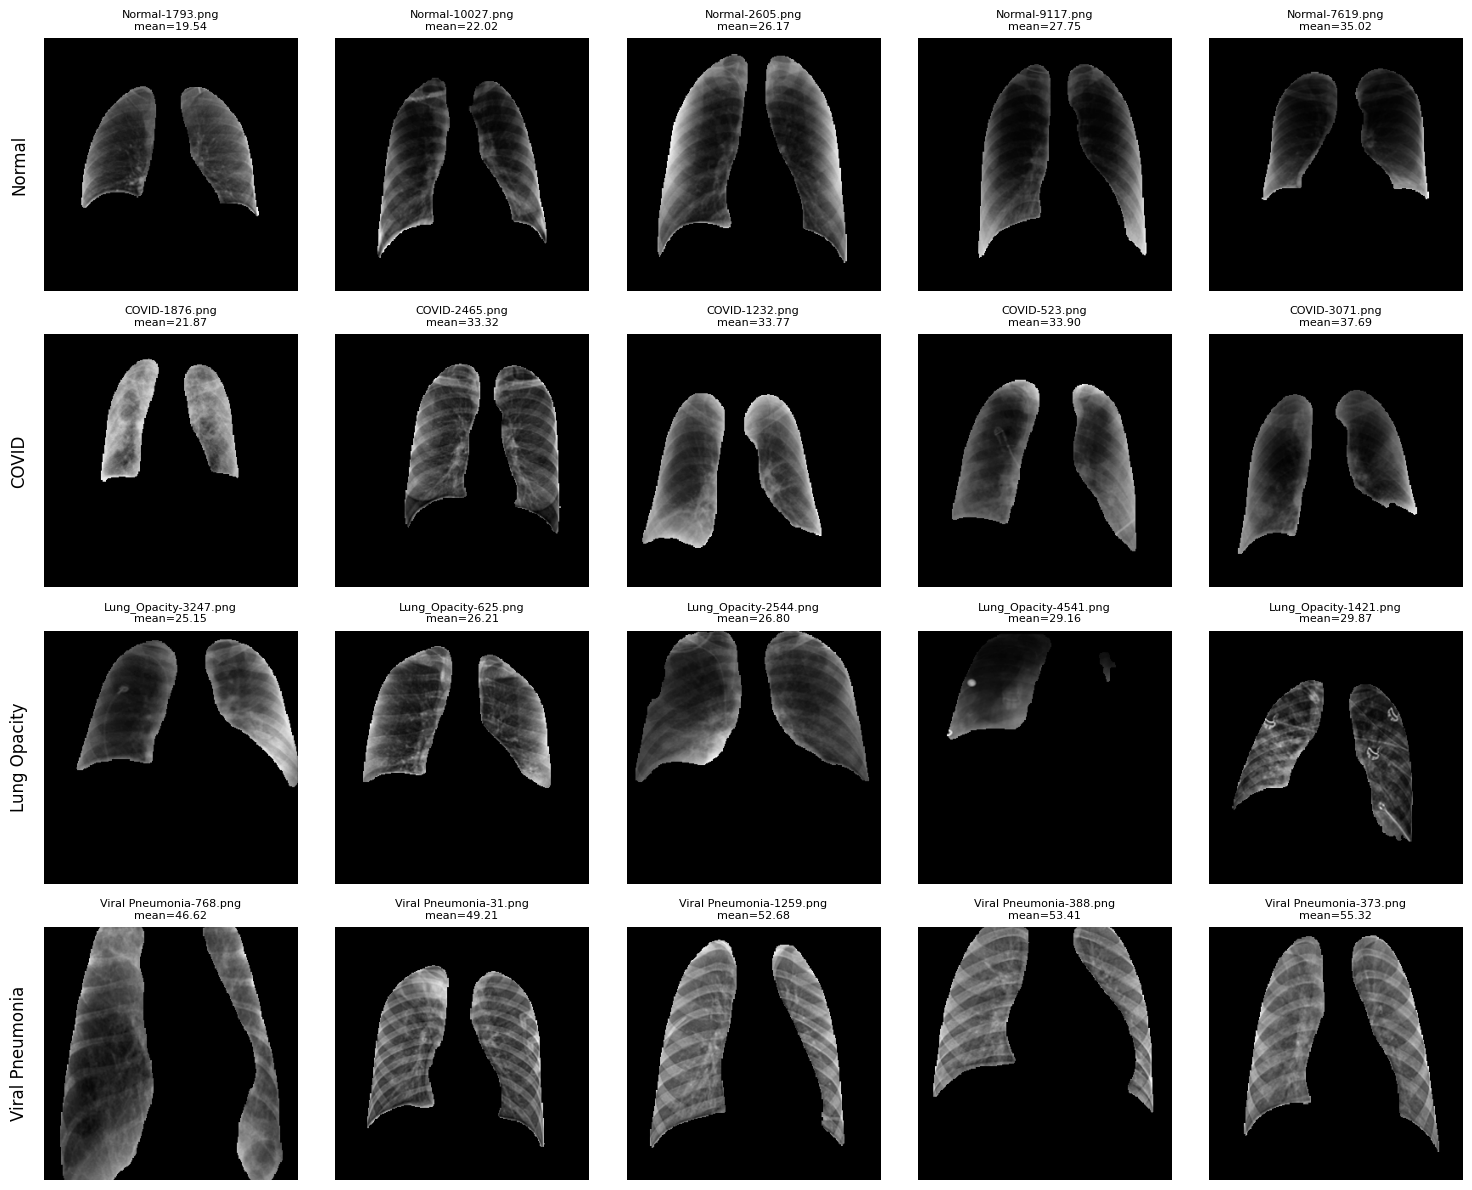

In [ ]:
# 5 images avec les moyennes les plus faibles par classe

classes = ["Normal", "COVID", "Lung Opacity", "Viral Pneumonia"]

fig, axs = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for row_idx, cls in enumerate(classes):
    
    class_images = (df_stats[df_stats["class"] == cls].nsmallest(5, "mean_pixel_masked"))
    
    for col_idx, (_, row) in enumerate(class_images.iterrows()):
        ax = axs[row_idx, col_idx]
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask_path = image_path.replace("images", "masks")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_resized > 0).astype(image.dtype)
        masked_image = image * mask_bin
        ax.imshow(masked_image, cmap="gray")
        ax.set_title(f"{row['image_name']}\nmean={row['mean_pixel_masked']:.2f}",fontsize=8)
        ax.axis("off")

    # nom de la classe à gauche de la ligne
    axs[row_idx, 0].text(
        -0.10, 0.5,
        cls,
        transform=axs[row_idx, 0].transAxes,
        fontsize=12,
        rotation=90,
        va="center",
        ha="center"
    )

plt.tight_layout()
plt.show()

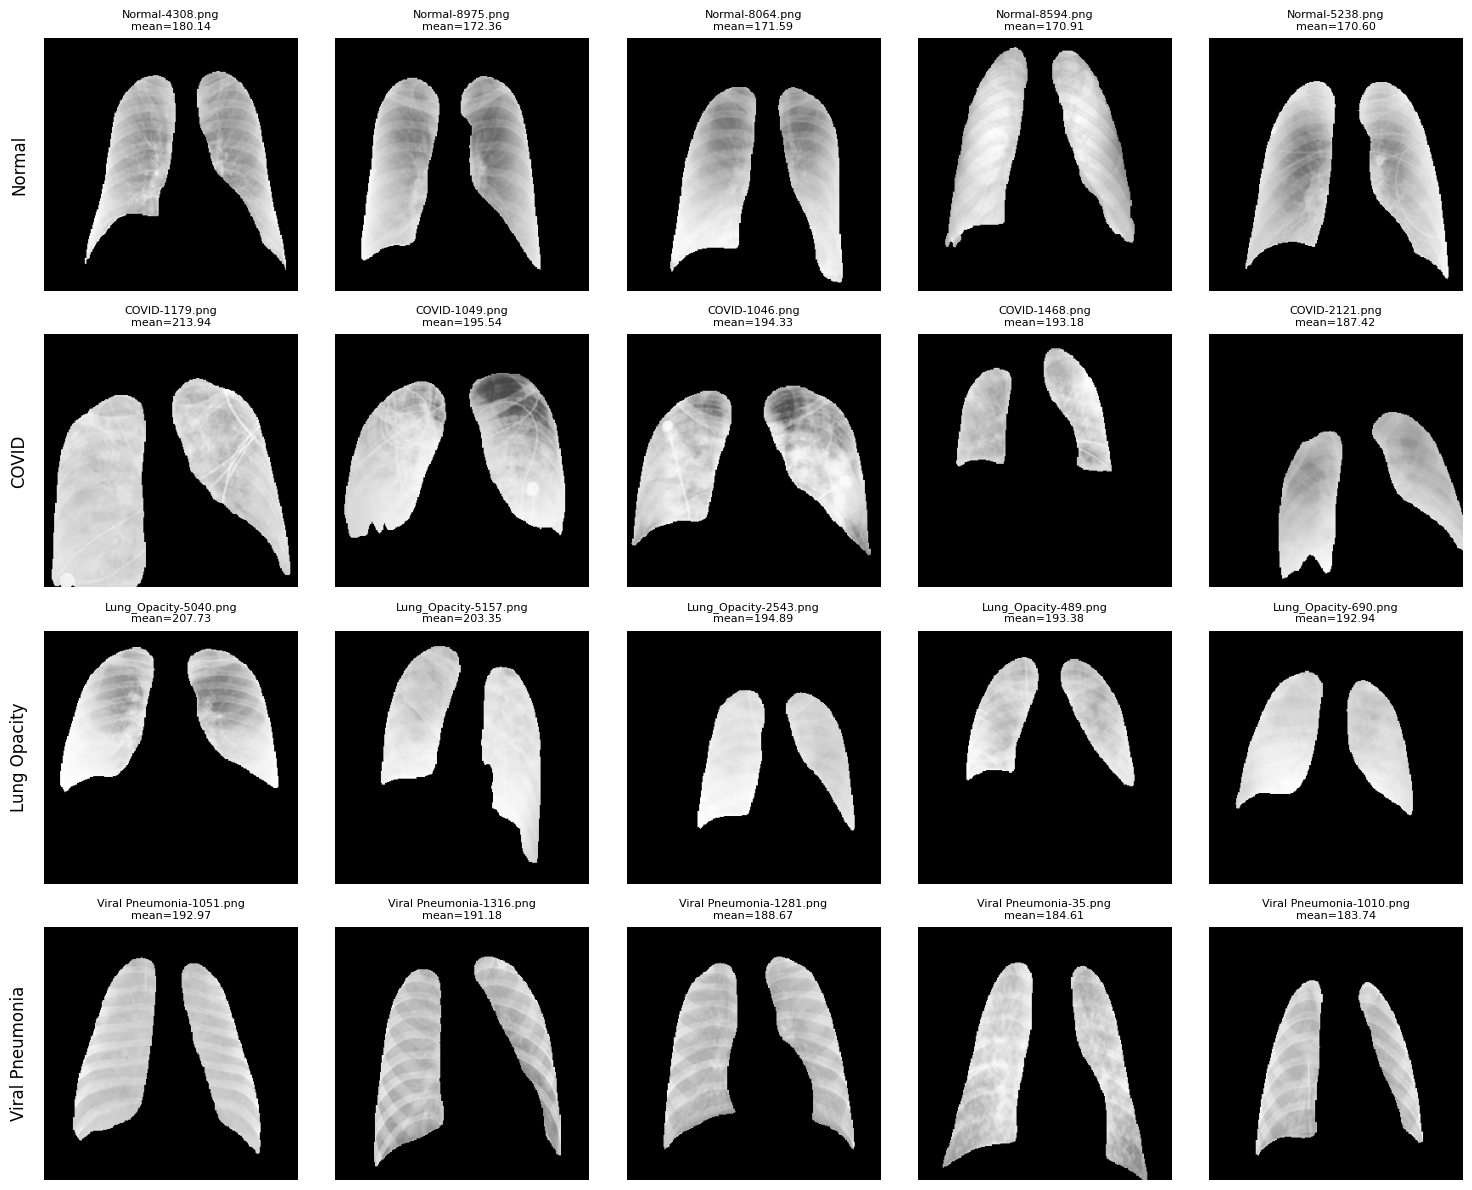

In [ ]:
# 5 images avec les moyennes les plus élevées par classe

classes = ["Normal", "COVID", "Lung Opacity", "Viral Pneumonia"]

fig, axs = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for row_idx, cls in enumerate(classes):
    
    class_images = (df_stats[df_stats["class"] == cls].nlargest(5, "mean_pixel_masked"))
    
    for col_idx, (_, row) in enumerate(class_images.iterrows()):
        ax = axs[row_idx, col_idx]
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask_path = image_path.replace("images", "masks")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_resized > 0).astype(image.dtype)
        masked_image = image * mask_bin
        ax.imshow(masked_image, cmap="gray")
        ax.set_title(f"{row['image_name']}\nmean={row['mean_pixel_masked']:.2f}",fontsize=8)
        ax.axis("off")

    # nom de la classe à gauche de la ligne
    axs[row_idx, 0].text(
        -0.10, 0.5,
        cls,
        transform=axs[row_idx, 0].transAxes,
        fontsize=12,
        rotation=90,
        va="center",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Standard deviation in segmented area

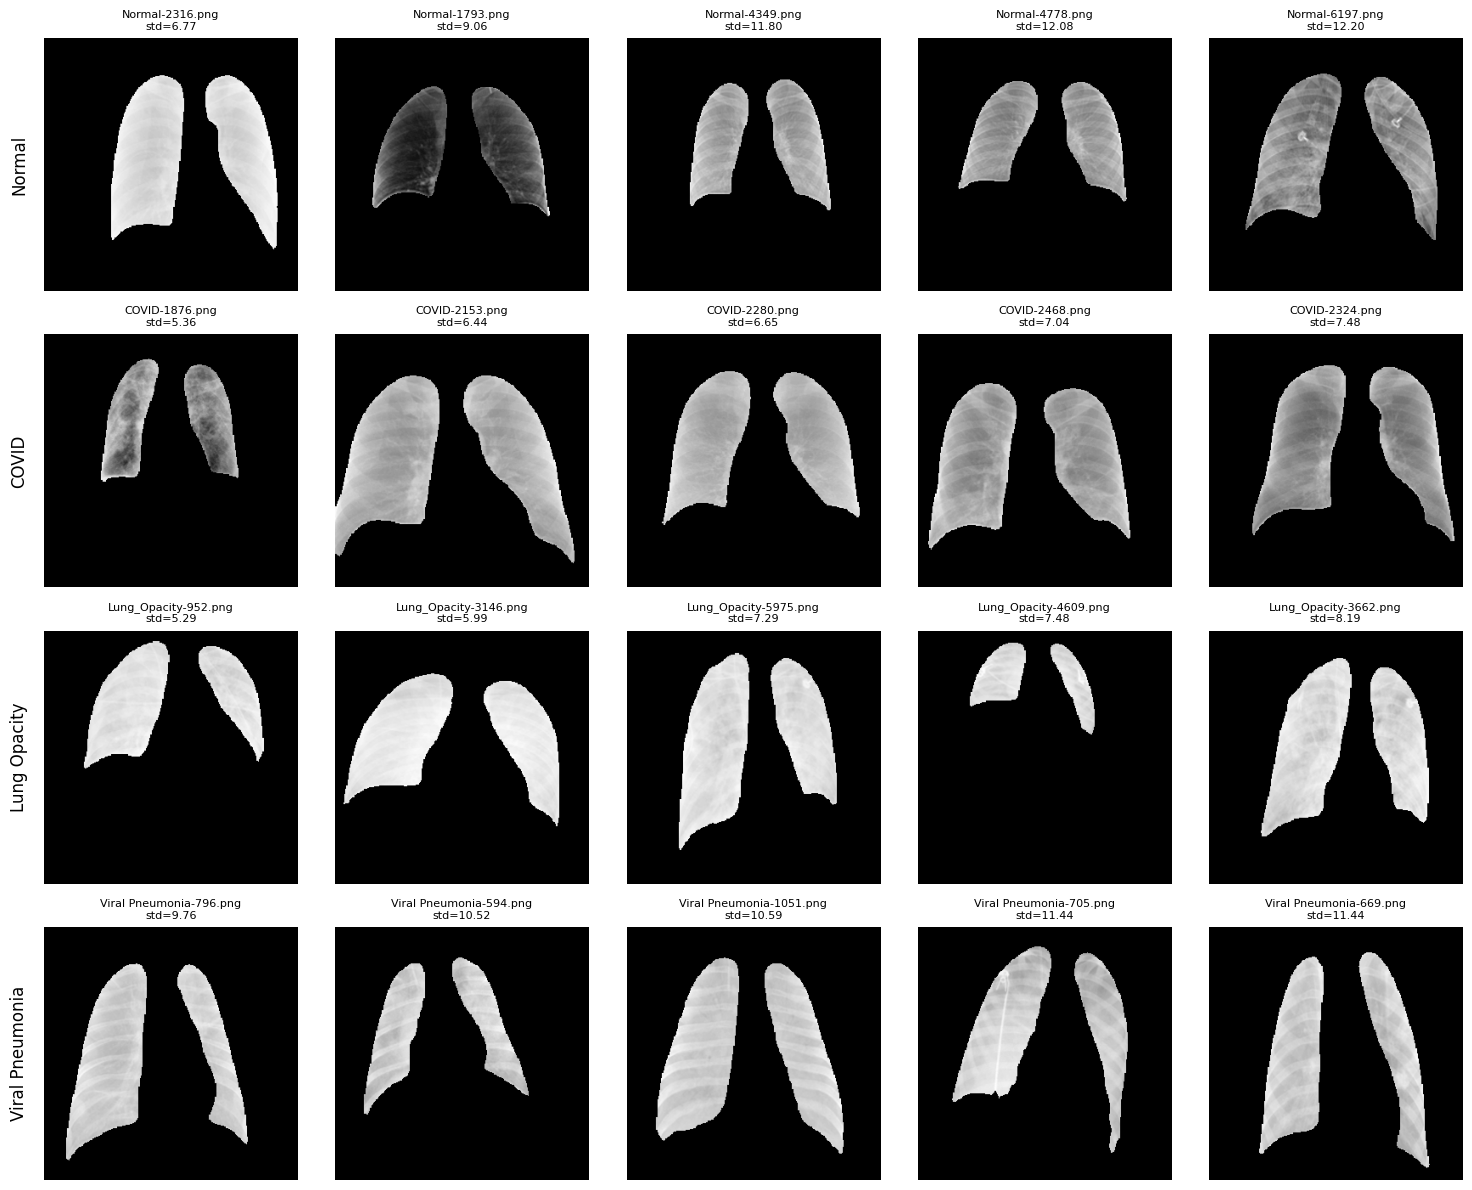

In [169]:
# 5 images avec les écart-types les plus faibles par classe

classes = ["Normal", "COVID", "Lung Opacity", "Viral Pneumonia"]

fig, axs = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for row_idx, cls in enumerate(classes):
    
    class_images = (df_stats[df_stats["class"] == cls].nsmallest(5, "std_pixel_masked"))
    
    for col_idx, (_, row) in enumerate(class_images.iterrows()):
        ax = axs[row_idx, col_idx]
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask_path = image_path.replace("images", "masks")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_resized > 0).astype(image.dtype)
        masked_image = image * mask_bin
        ax.imshow(masked_image, cmap="gray")
        ax.set_title(f"{row['image_name']}\nstd={row['std_pixel_masked']:.2f}",fontsize=8)
        ax.axis("off")

    # nom de la classe à gauche de la ligne
    axs[row_idx, 0].text(
        -0.10, 0.5,
        cls,
        transform=axs[row_idx, 0].transAxes,
        fontsize=12,
        rotation=90,
        va="center",
        ha="center"
    )

plt.tight_layout()
plt.show()

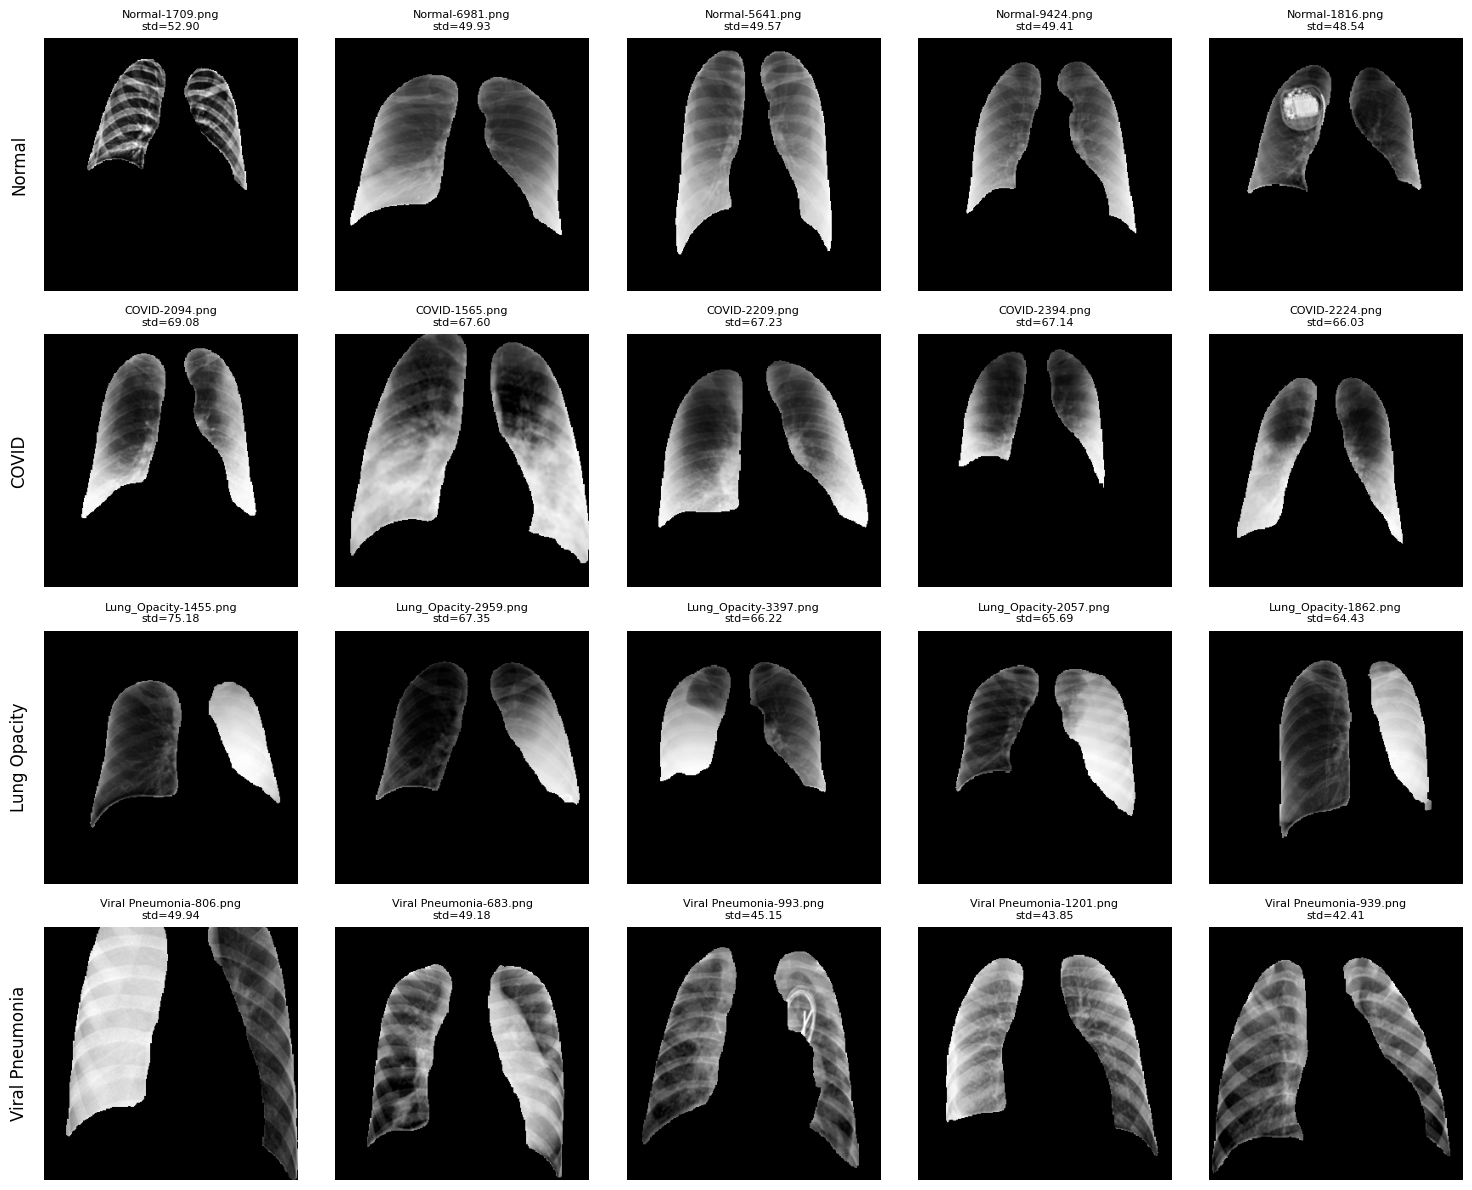

In [ ]:
# 5 images avec les écart-types les plus élevés par classe

classes = ["Normal", "COVID", "Lung Opacity", "Viral Pneumonia"]

fig, axs = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for row_idx, cls in enumerate(classes):
    
    class_images = (df_stats[df_stats["class"] == cls].nlargest(5, "std_pixel_masked"))
    
    for col_idx, (_, row) in enumerate(class_images.iterrows()):
        ax = axs[row_idx, col_idx]
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask_path = image_path.replace("images", "masks")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_resized > 0).astype(image.dtype)
        masked_image = image * mask_bin
        ax.imshow(masked_image, cmap="gray")
        ax.set_title(f"{row['image_name']}\nstd={row['std_pixel_masked']:.2f}",fontsize=8)
        ax.axis("off")

    # nom de la classe à gauche de la ligne
    axs[row_idx, 0].text(
        -0.10, 0.5,
        cls,
        transform=axs[row_idx, 0].transAxes,
        fontsize=12,
        rotation=90,
        va="center",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Zero ratio in masked images

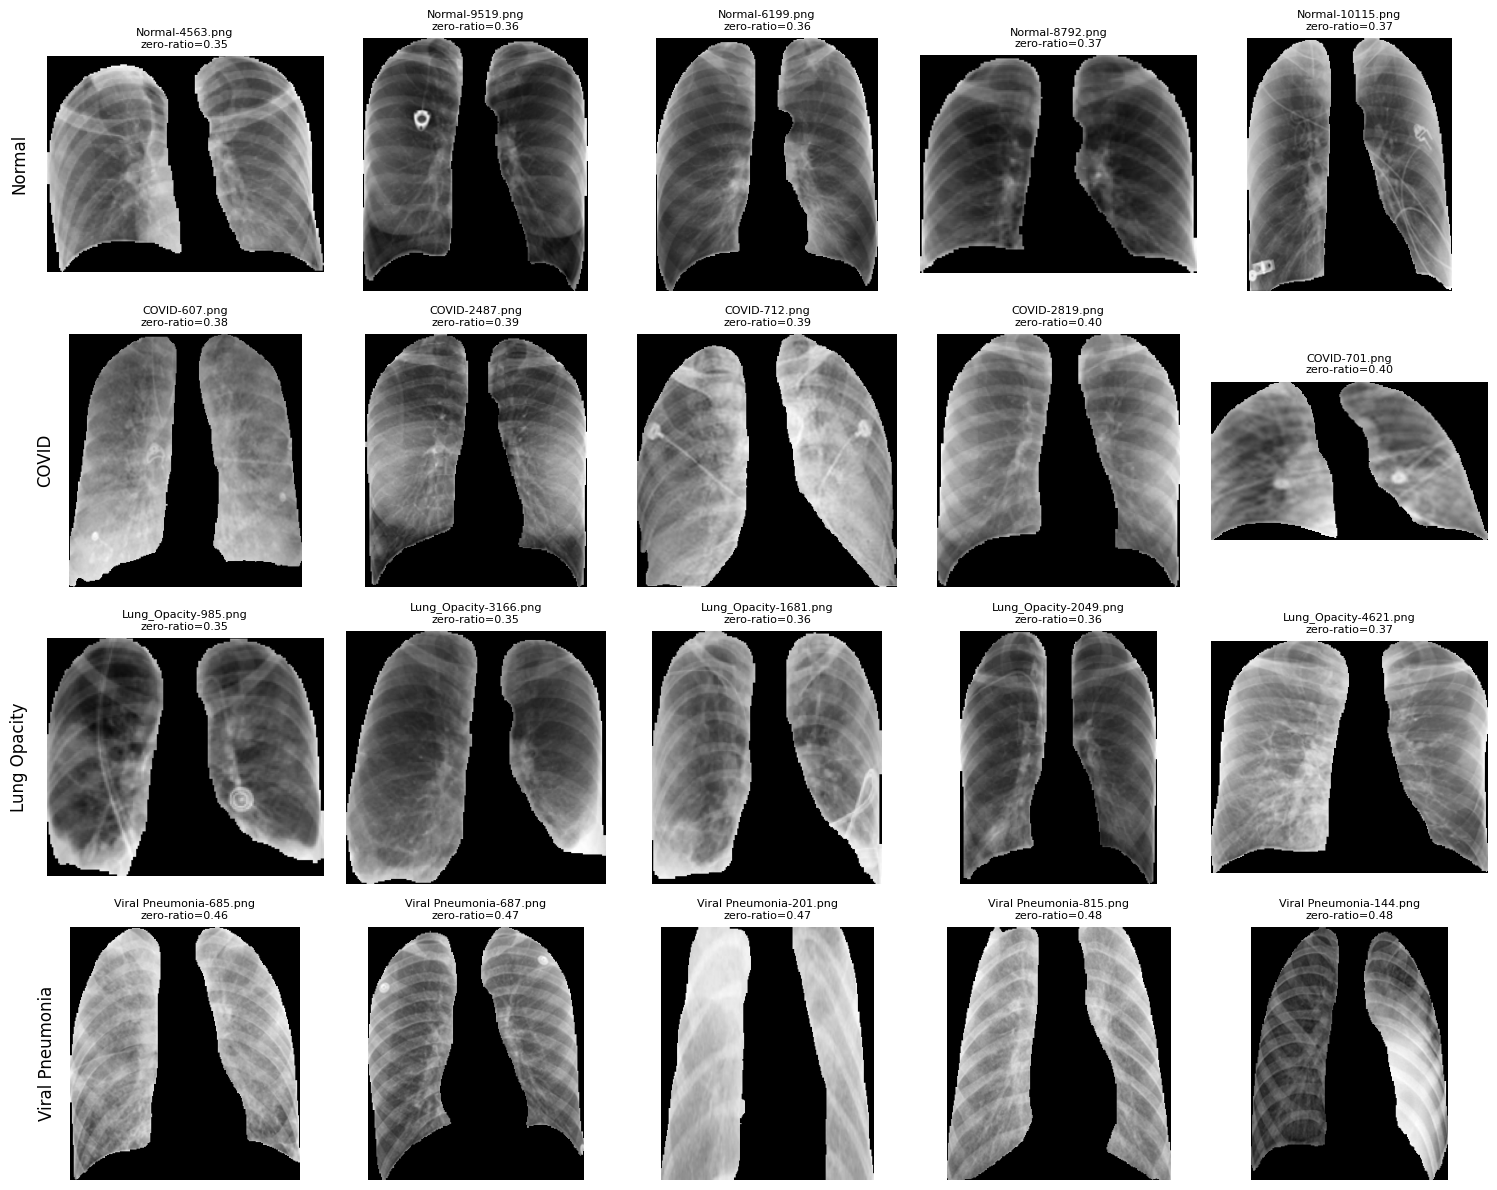

In [175]:
# 5 images masquées recadrées avec les ratios de pixels noirs les plus faibles par classe

classes = ["Normal", "COVID", "Lung Opacity", "Viral Pneumonia"]

fig, axs = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for row_idx, cls in enumerate(classes):
    
    class_images = (df_stats[df_stats["class"] == cls].nsmallest(5, "zero_ratio_masked"))
    
    for col_idx, (_, row) in enumerate(class_images.iterrows()):
        ax = axs[row_idx, col_idx]
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask_path = image_path.replace("images", "masks")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_resized > 0).astype(image.dtype)
        masked_image = image * mask_bin
        ax.imshow(crop_black_borders(masked_image), cmap="gray")
        ax.set_title(f"{row['image_name']}\nzero-ratio={row['zero_ratio_masked']:.2f}",fontsize=8)
        ax.axis("off")

    # nom de la classe à gauche de la ligne
    axs[row_idx, 0].text(
        -0.10, 0.5,
        cls,
        transform=axs[row_idx, 0].transAxes,
        fontsize=12,
        rotation=90,
        va="center",
        ha="center"
    )

plt.tight_layout()
plt.show()

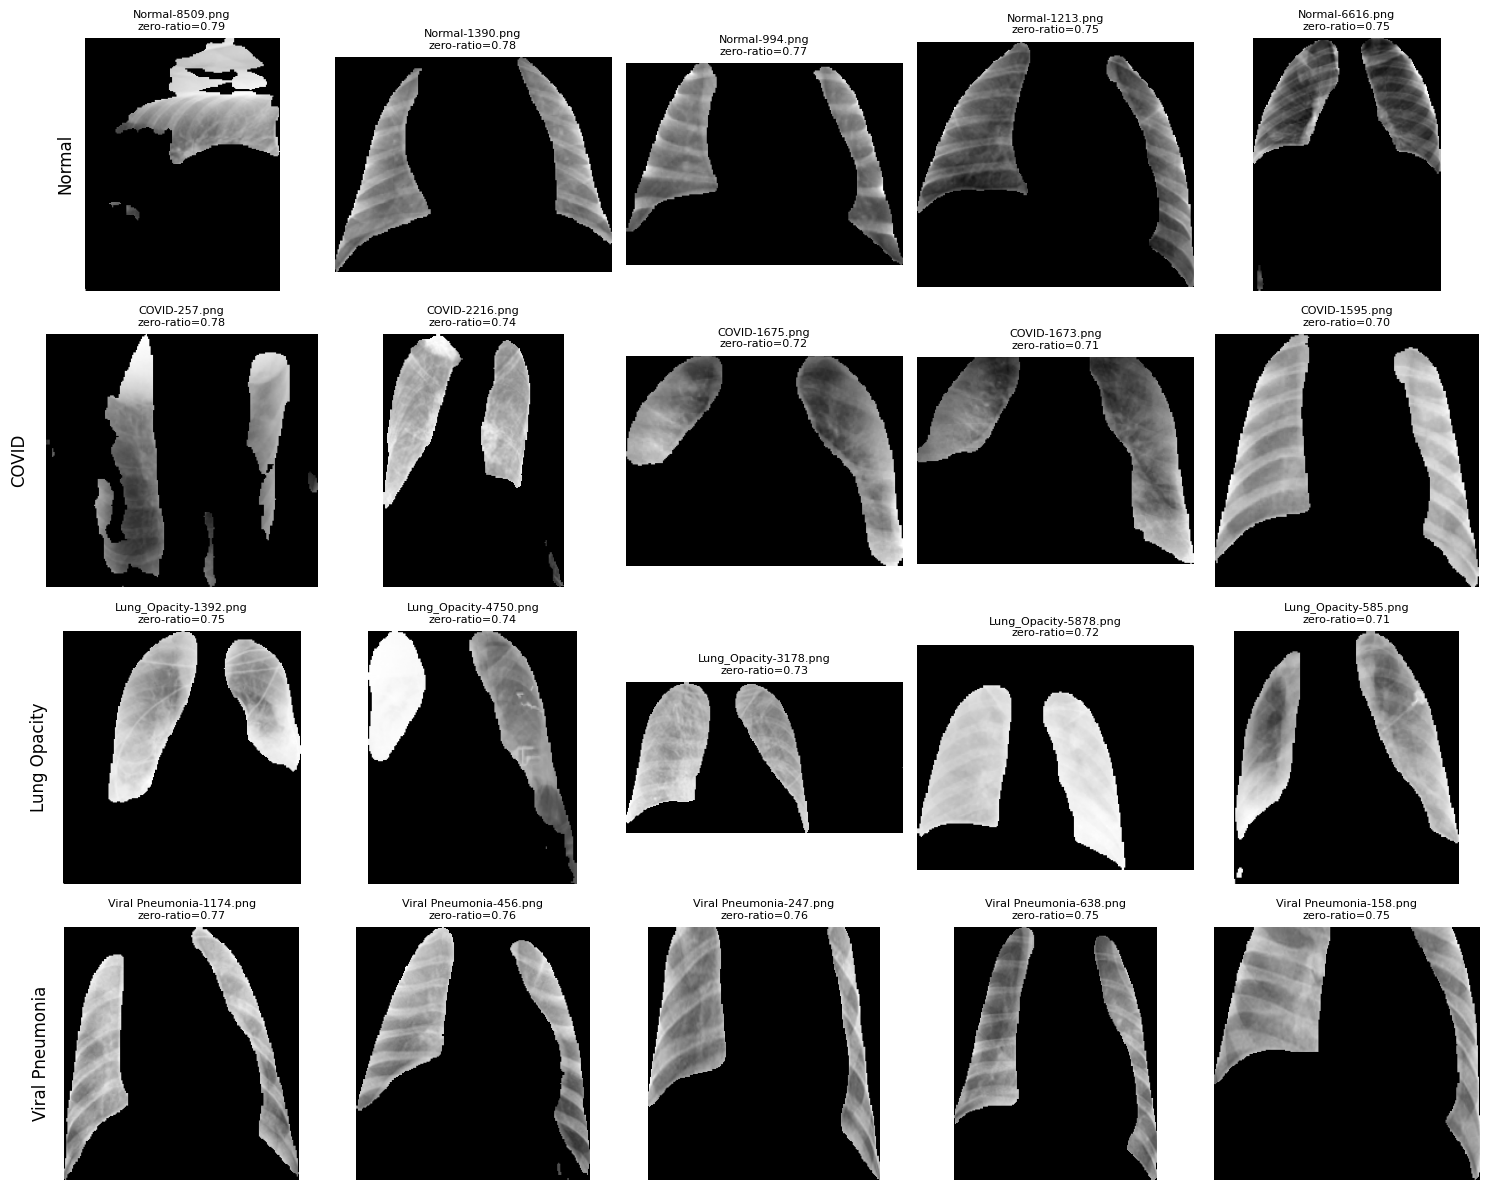

In [176]:
# 5 images masquées recadrées avec les ratios de pixels noirs les plus élevés par classe

classes = ["Normal", "COVID", "Lung Opacity", "Viral Pneumonia"]

fig, axs = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for row_idx, cls in enumerate(classes):
    
    class_images = (df_stats[df_stats["class"] == cls].nlargest(5, "zero_ratio_masked"))
    
    for col_idx, (_, row) in enumerate(class_images.iterrows()):
        ax = axs[row_idx, col_idx]
        image_path = os.path.join(paths[row["class"]], row["image_name"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask_path = image_path.replace("images", "masks")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_resized > 0).astype(image.dtype)
        masked_image = image * mask_bin
        ax.imshow(crop_black_borders(masked_image), cmap="gray")
        ax.set_title(f"{row['image_name']}\nzero-ratio={row['zero_ratio_masked']:.2f}",fontsize=8)
        ax.axis("off")

    # nom de la classe à gauche de la ligne
    axs[row_idx, 0].text(
        -0.10, 0.5,
        cls,
        transform=axs[row_idx, 0].transAxes,
        fontsize=12,
        rotation=90,
        va="center",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Recadrage

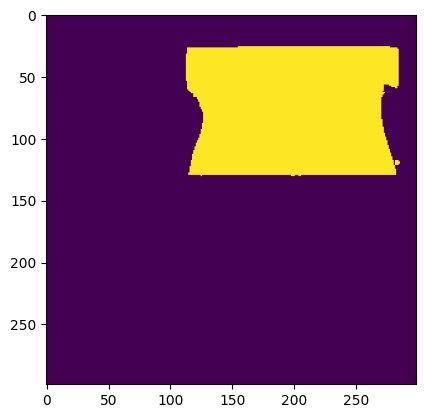

In [88]:
def analyze_padding(image, threshold=1):
    _, binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(binary)
    x, y, w, h = cv2.boundingRect(coords)
    cropped_image = image[y:y+h, x:x+w]
    return binary

plt.imshow(analyze_padding(cv2.imread("C:/Users/azizc/projects/Analysis-of-COVID-19-Chest-X-rays/data/padded/COVID/COVID-3615.png", cv2.IMREAD_GRAYSCALE)))

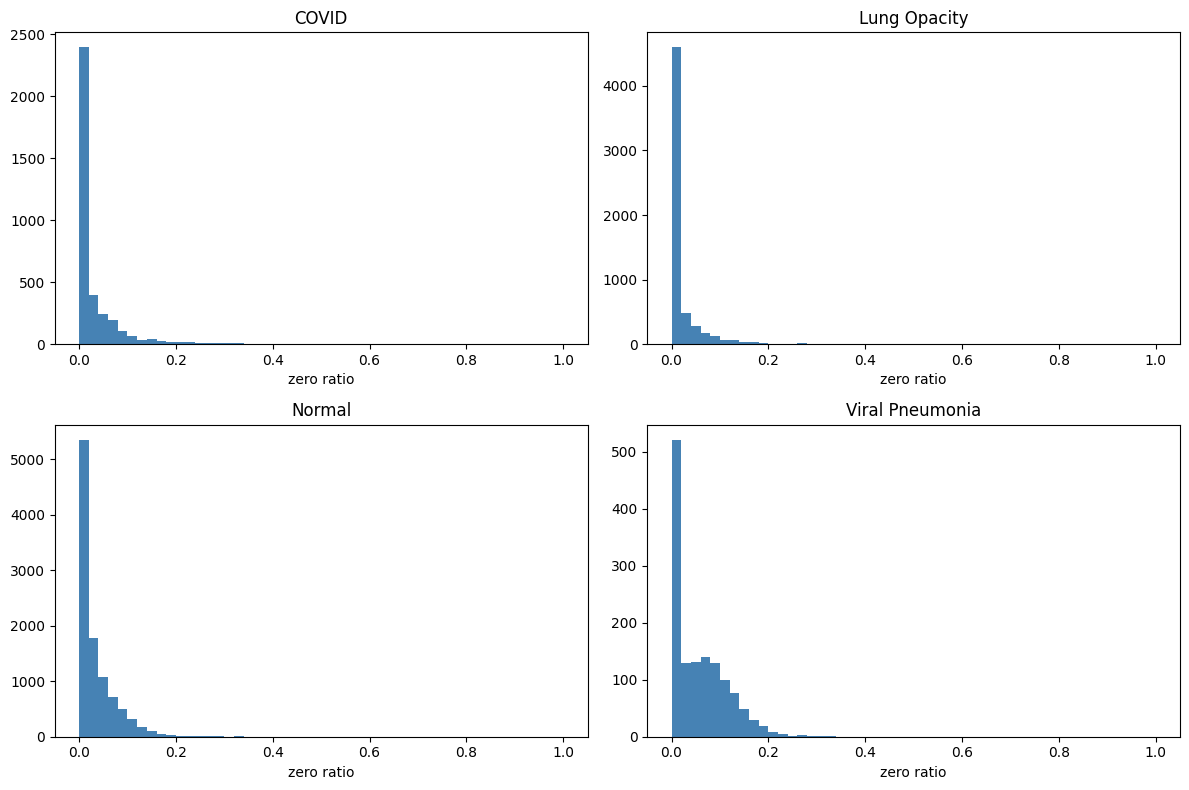

In [96]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, cls_name in zip(axs.flat, classes):
    data = df_stats[df_stats["class"] == cls_name]["zeros"]
    ax.hist(data, bins=50, range=(0, 1), color='steelblue', edgecolor='none')
    ax.set_title(cls_name)
    ax.set_xlabel("zero ratio")

plt.tight_layout()
plt.show()

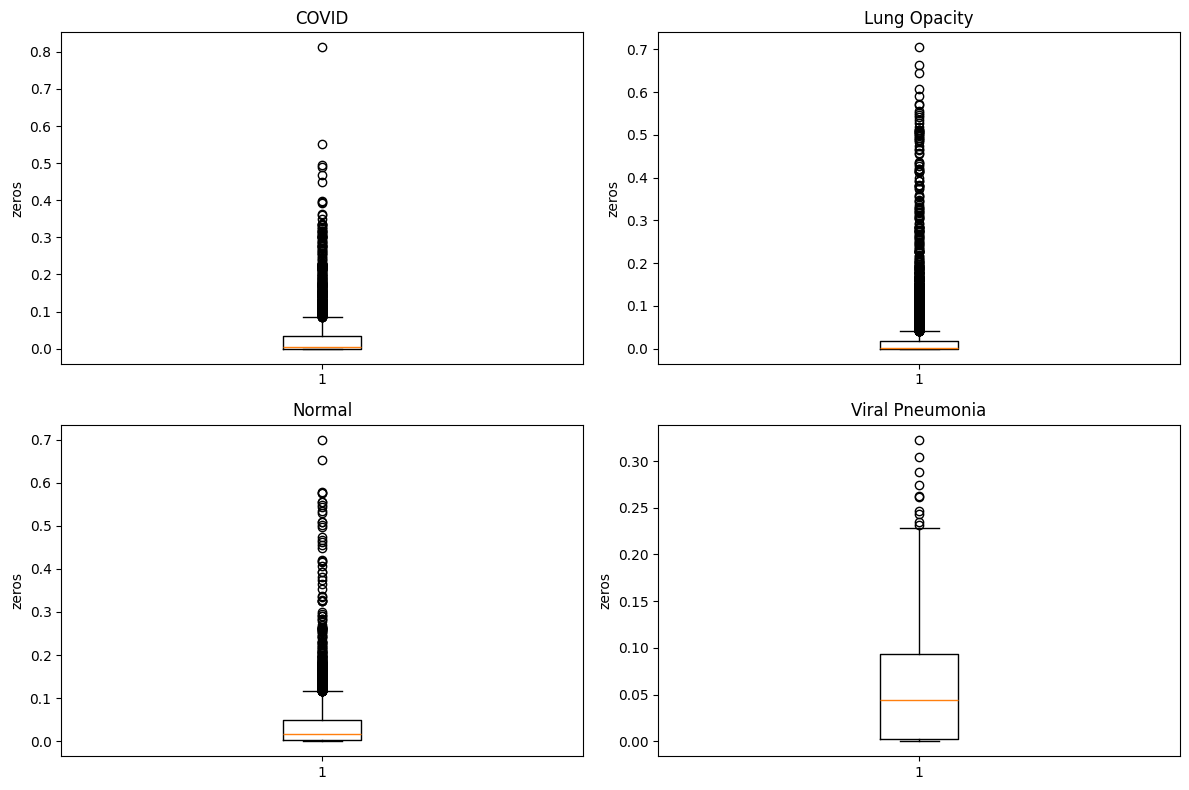

In [97]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, cls_name in zip(axs.flat, classes):
    data = df_stats[df_stats["class"] == cls_name]["zeros"]
    ax.boxplot(data, vert=True)
    ax.set_title(cls_name)
    ax.set_ylabel("zeros")

plt.tight_layout()
plt.show()

In [61]:
def analyze_uncropped_images(class_name):
    path = paths[class_name]
    count = 0
    for fname in os.listdir(path):
        img = (plt.imread(os.path.join(path, fname)).astype(np.uint8))
        if (img == 0).sum()/ img.size >= 0.4:
            count +=1
    return count


analyze_uncropped_images("Normal")

10192

### Display outliers

In [134]:
def show_outliers(df, feature, class_name=None, n=20, pos="min"):

    data = df.copy()

    if class_name is not None:
        data = data[data["class"] == class_name]

    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[feature] < lower) |
        (data[feature] > upper)
    ].sort_values(feature)

    print(f"{len(outliers)} outliers found")
    
    if pos == "min":
        outliers = outliers.head(n)
    elif pos == "max":
        outliers = outliers.tail(n)

    fig, axs = plt.subplots(
        int(np.ceil(len(outliers)/5)),
        5,
        figsize=(15, 3 * int(np.ceil(len(outliers)/5)))
    )

    axs = np.array(axs).flatten()

    for ax, (_, row) in zip(axs, outliers.iterrows()):

        image_path = os.path.join(
            paths[row["class"]],
            row["image_name"]
        )
        mask_path = image_path.replace("images", "masks")

        image = plt.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        mask = plt.imread(mask_path)
        mask_gray = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
        mask_resized = cv2.resize(mask_gray, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_resized > 0).astype(image.dtype)
        masked_image = image * mask_bin

        ax.imshow(masked_image, cmap="gray")

        ax.set_title(
            f"{row['image_name']}\n{feature}={row[feature]:.2f}",
            fontsize=8
        )

        ax.axis("off")

    for ax in axs[len(outliers):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

506 outliers found


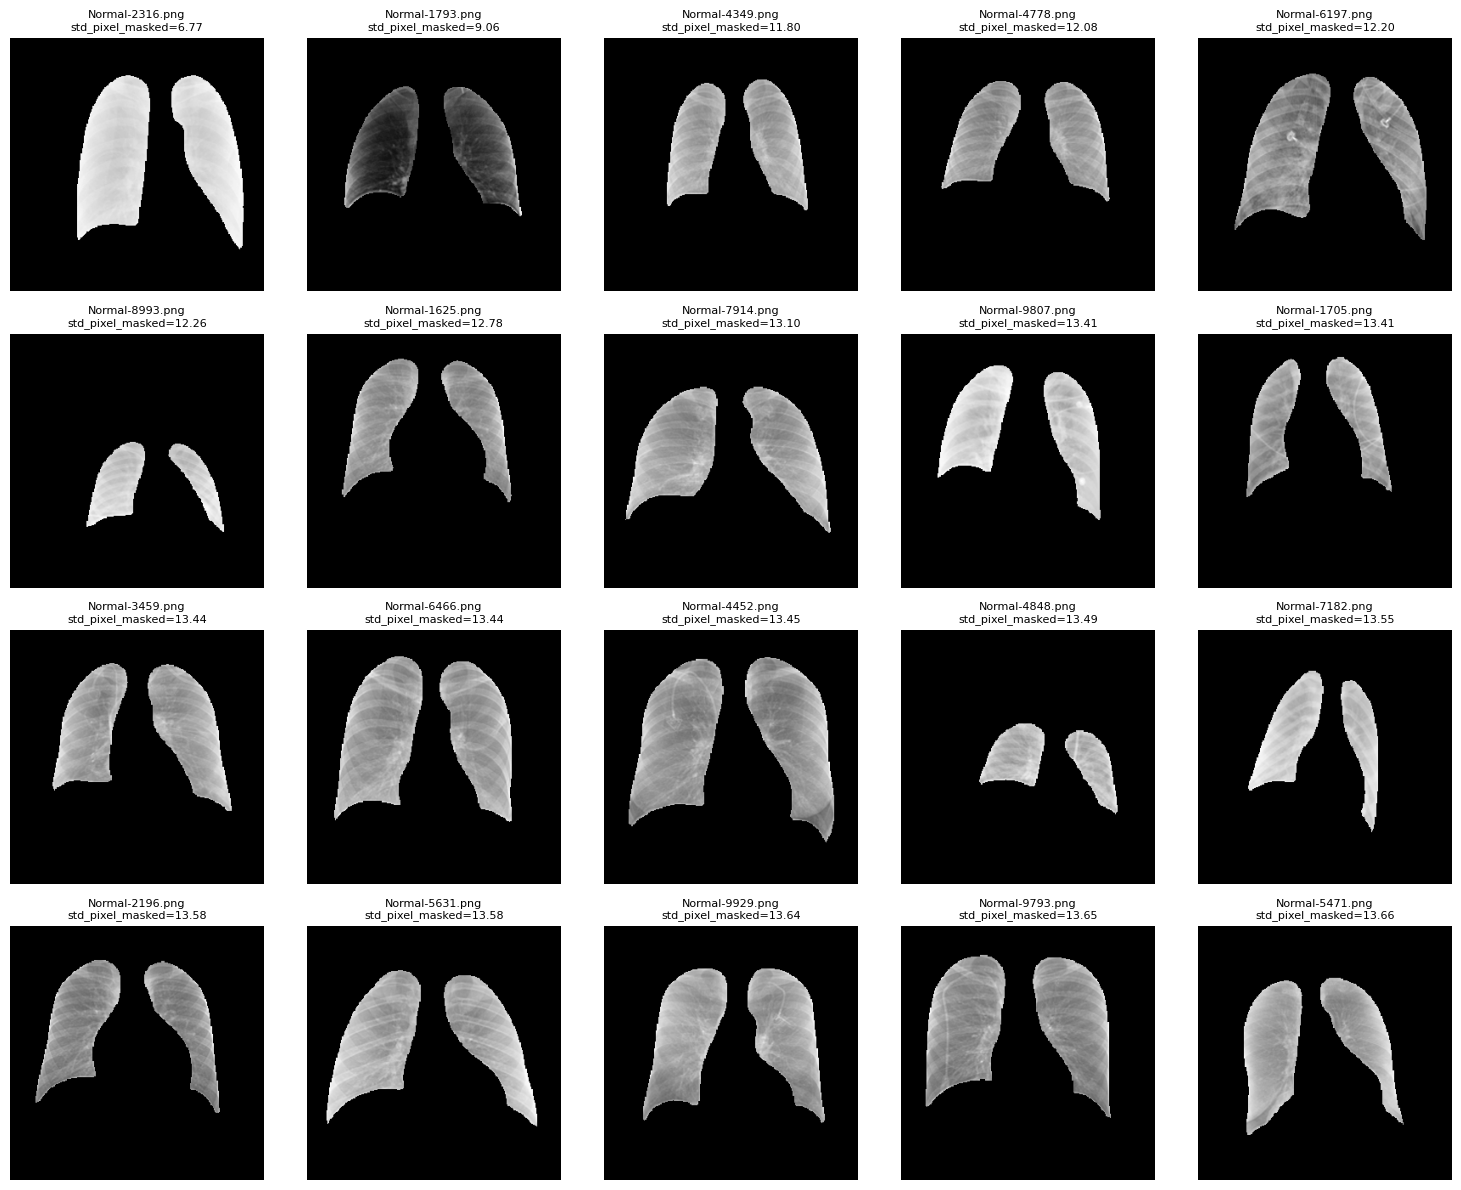

506 outliers found


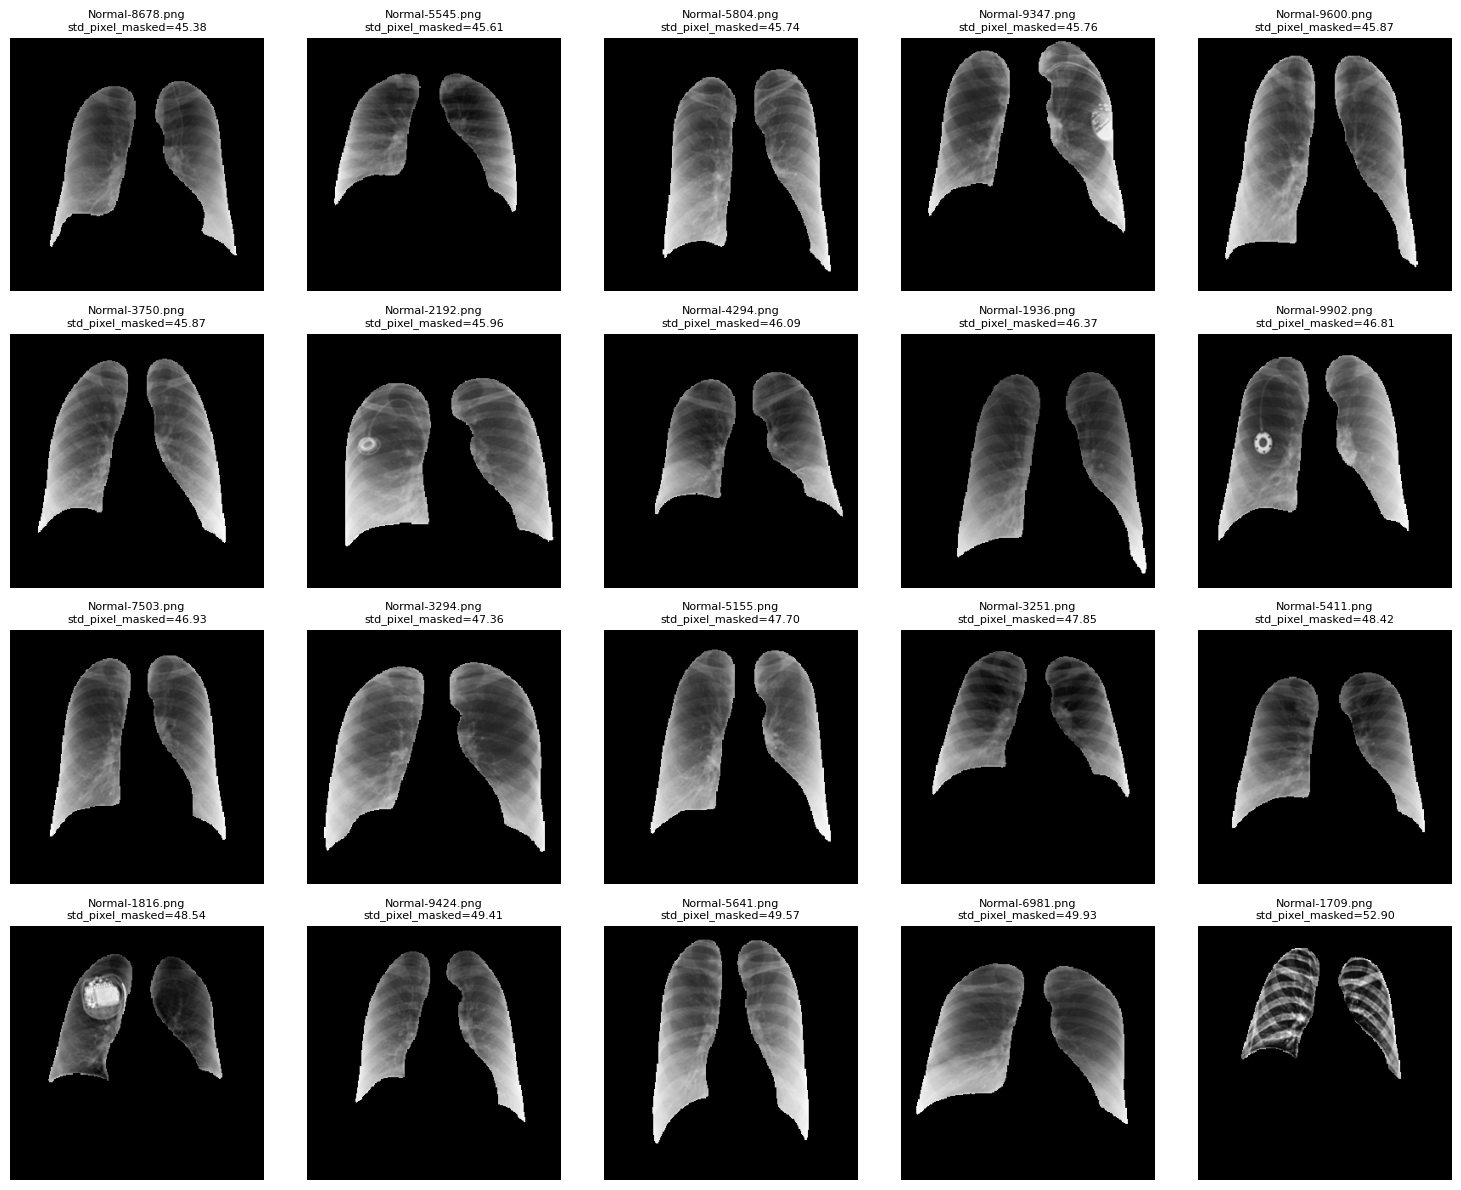

In [150]:
n = 20

classes = [
    "Normal",
    # "COVID",
    # "Lung Opacity",
    # "Viral Pneumonia"
    ]

features = [
    # "mean_pixel_masked",
    "std_pixel_masked",
    # "pixel_qty_masked",
    # "zero_ratio_masked"
    ]


for feature in features:
    for class_name in classes:
        show_outliers(
            df_stats,
            feature=feature,
            class_name=class_name,
            n=n,
            pos="min",
        )
        
for feature in features:
    for class_name in classes:
        show_outliers(
            df_stats,
            feature=feature,
            class_name=class_name,
            n=n,
            pos="max",
        )